In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import umap.umap_ as umap
from lightgbm import LGBMClassifier
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE # LLE, UMAP
from sklearn.manifold import trustworthiness
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
#from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# caracteristicas de las imagenes: 10pts tamaño titulos ,etiquetas ejes 9 pts, leyendas 8pts, font family serif, formato de imagen tiff

In [3]:
# ==========================================
# CONFIGURACIÓN GLOBAL DE ESTILO PARA MDPI
# ==========================================
# 1. Familia de la fuente
plt.rcParams['font.family'] = 'serif'

# 2. Tamaños de fuente solicitados
plt.rcParams['axes.titlesize'] = 10     # Tamaño de los títulos
plt.rcParams['axes.labelsize'] = 9      # Tamaño de las etiquetas de los ejes (X e Y)
plt.rcParams['legend.fontsize'] = 8     # Tamaño de la leyenda
plt.rcParams['xtick.labelsize'] = 8     # Tamaño de los números en el eje X
plt.rcParams['ytick.labelsize'] = 8     # Tamaño de los números en el eje Y

# 3. Configuraciones de exportación por defecto
plt.rcParams['savefig.dpi'] = 300       # Resolución de alta calidad (obligatorio en revistas)
plt.rcParams['savefig.format'] = 'tiff' # Formato de imagen por defecto
plt.rcParams['savefig.bbox'] = 'tight'  # Evita que se recorten los bordes al guardar

In [4]:
biolog_limit = {
    'ap_hi_min': 60, 'ap_hi_max': 250,
    'height_min': 1.00, 'height_max': 2.20,
    'weight_min': 35, 'weight_max': 250
}

# la base de datos cardio_train será la matriz A con output y 3-variables será B quitando output
# Primera base de datos con cardio-------------------------------------------
dfA = pd.read_csv('cardio_train_1.csv',sep=';')
dfA['age'] = dfA['age']/365
dfA['height'] = dfA['height']/100
dfA.drop('id',axis=1,inplace=True) # quitar columna id y axis=1 es para buscar en las columnas
print(f"Columns of database A: {dfA.columns}")

# Segunda base de datos-----------------------------------------------------
# Revisar lo de quitar índice de masa corporal bmi
dfB = pd.read_csv('3-Variables-to-cardiovascular-disease.csv',sep=',')
dfB = dfB.dropna()
CardioB = dfB['cardio']
dfB["height"] = dfB["height"]/100
dfB.rename(columns={'age_years': 'age'}, inplace=True)
dfB.drop("id ",axis=1,inplace=True) # quitar columna id y axis=1 es para buscar en las columnas
dfB.drop('cardio',axis=1,inplace=True) # quitar columna cardio y axis=1 es para buscar en las columnas
dfB.drop('bmi',axis=1,inplace=True) # quitar columna bmi y axis=1 es para buscar en las columnas
dfB.dropna()
print(f"Columns of database B: {dfB.columns}")





Columns of database A: Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')
Columns of database B: Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'cholesterol', 'gluc',
       'smoke', 'alco', 'active'],
      dtype='object')


In [5]:
# 2. Creación de la máscara booleana (condiciones concurrentes)

dfA2=dfA
dfA2.drop('ap_lo',axis=1,inplace=True) # quitar columna cardio y axis=1 es para buscar en las columnas

mascara_biologica = (
    (dfA2['ap_hi'] >= biolog_limit['ap_hi_min']) & (dfA2['ap_hi'] <= biolog_limit['ap_hi_max']) &
    (dfA2['height'] >= biolog_limit['height_min']) & (dfA2['height'] <= biolog_limit['height_max']) &
    (dfA2['weight'] >= biolog_limit['weight_min']) & (dfA2['weight'] <= biolog_limit['weight_max'])
)

# 3. Aplicación del filtro y creación de un DataFrame limpio e independiente
dfA2_limpio = dfA2[mascara_biologica].copy()
cardioA = dfA2_limpio['cardio']
dfA2_limpio.drop('cardio',axis=1,inplace=True) # quitar columna cardio y axis=1 es para buscar en las columnas

# 4. Verificación en consola de los registros procesados
registros_originales = len(dfA)
registros_finales = len(dfA2_limpio)
registros_eliminados = registros_originales - registros_finales



print("-" * 30)
print(f"Registros originales: {registros_originales}")
print(f"Registros limpios:    {registros_finales}")
print(f"Atípicos eliminados:  {registros_eliminados}")
print("-" * 30)

# Guardar el DataFrame limpio en un nuevo archivo CSV
dfA2_limpio.to_csv('cardio_train_limpio.csv', index=False)

------------------------------
Registros originales: 70000
Registros limpios:    69724
Atípicos eliminados:  276
------------------------------


In [6]:
# esta base de datos al tener mas entradas será la de entrenamiento principal
dfA2_limpio.info() #---- Instrucción para ver datos faltantes
dfA2_limpio.describe() # ----- medidas de tendencia central


<class 'pandas.core.frame.DataFrame'>
Index: 69724 entries, 0 to 69999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          69724 non-null  float64
 1   gender       69724 non-null  int64  
 2   height       69724 non-null  float64
 3   weight       69724 non-null  float64
 4   ap_hi        69724 non-null  int64  
 5   cholesterol  69724 non-null  int64  
 6   gluc         69724 non-null  int64  
 7   smoke        69724 non-null  int64  
 8   alco         69724 non-null  int64  
 9   active       69724 non-null  int64  
dtypes: float64(3), int64(7)
memory usage: 5.9 MB


,age,gender,height,weight,ap_hi,cholesterol,gluc,smoke,alco,active
count,69724.000000,69724.000000,69724.000000,69724.000000,69724.000000,69724.000000,69724.000000,69724.000000,69724.000000,69724.000000
mean,53.341028,1.349607,1.643972,74.221297,127.004805,1.367234,1.226636,0.088291,0.053827,0.803783
std,6.758513,0.476849,0.079844,14.363372,17.096129,0.680633,0.572457,0.283720,0.225677,0.397137
min,29.583562,1.000000,1.000000,35.000000,60.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,48.399315,1.000000,1.590000,65.000000,120.000000,1.000000,1.000000,0.000000,0.000000,1.000000
50%,53.980822,1.000000,1.650000,72.000000,120.000000,1.000000,1.000000,0.000000,0.000000,1.000000
75%,58.430137,2.000000,1.700000,82.000000,140.000000,2.000000,1.000000,0.000000,0.000000,1.000000
max,64.967123,2.000000,2.070000,200.000000,240.000000,3.000000,3.000000,1.000000,1.000000,1.000000


In [7]:
# menos datos (219) database de test cardio
dfB.info()
dfB.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 219 entries, 0 to 218
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          219 non-null    float64
 1   gender       219 non-null    float64
 2   height       219 non-null    float64
 3   weight       219 non-null    float64
 4   ap_hi        219 non-null    float64
 5   cholesterol  219 non-null    float64
 6   gluc         219 non-null    float64
 7   smoke        219 non-null    float64
 8   alco         219 non-null    float64
 9   active       219 non-null    float64
dtypes: float64(10)
memory usage: 18.8 KB


,age,gender,height,weight,ap_hi,cholesterol,gluc,smoke,alco,active
count,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000
mean,53.009132,1.406393,1.650639,72.986301,130.406393,1.369863,1.182648,0.105023,0.036530,0.776256
std,6.787057,0.492285,0.082848,14.231210,15.864511,0.674030,0.509965,0.307285,0.188034,0.417707
min,39.000000,1.000000,1.480000,45.000000,93.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,49.000000,1.000000,1.580000,63.000000,121.000000,1.000000,1.000000,0.000000,0.000000,1.000000
50%,53.000000,1.000000,1.650000,71.000000,128.000000,1.000000,1.000000,0.000000,0.000000,1.000000
75%,59.000000,2.000000,1.700000,82.000000,141.000000,2.000000,1.000000,0.000000,0.000000,1.000000
max,64.000000,2.000000,1.880000,115.000000,188.000000,3.000000,3.000000,1.000000,1.000000,1.000000


COMIENZO DE LA METODOLOGÍA
A la base de datos A hay que quitarle cardio y ap_lo para una concatenación correcta

In [8]:
# 1) Split ANTES de ajustar cualquier transformación
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    dfA2_limpio, cardioA, test_size=0.2, random_state=42, stratify=cardioA
)

# 2) Alineación explícita de columnas de B (no por orden implícito del CSV)
dfB = dfB[X_train_raw.columns]

In [9]:
# Escalado dividido antes de aplicar reducción de dimensionalidad
# escalar datos continuos y 'pegar' categóricos
escalador = StandardScaler()
X_train_scaled = escalador.fit_transform(X_train_raw)
X_test_scaled  = escalador.transform(X_test_raw)     # <- transform, no fit_transform
dfB_scaled     = escalador.transform(dfB)            # <- transform, no fit_transform


### usar otras técnicas de clustering como GMM.
### puede ser que pca y t-sne no sean los algoritmos mas ideales para la visualizacion

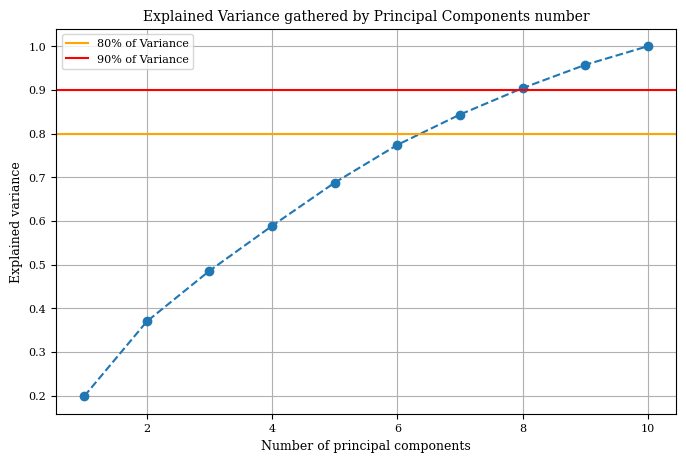

In [ ]:
# Selección de dimensiones basados en Varianza Explicada Acumulada

# 1. Instanciamos el PCA sin límite de componentes para verlos todos
pca_test = PCA()
pca_test.fit(X_train_scaled)

# 2. Calculamos la varianza explicada acumulada
# pca.explained_variance_ratio_ nos dice qué % de información tiene cada componente
varianza_acumulada = np.cumsum(pca_test.explained_variance_ratio_)

# 3. Graficamos la curva o "Scree Plot"
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--')

# Dibujamos líneas de referencia al 80% y 90% de información retenida
plt.axhline(y=0.80, color='orange', linestyle='-', label='80% of Variance')
plt.axhline(y=0.90, color='red', linestyle='-', label='90% of Variance')

plt.title('Explained Variance gathered by Principal Components number')
plt.xlabel('Number of principal components')
plt.ylabel('Explained variance')
plt.legend()
plt.grid(True)

plt.savefig(
    'target pca components.tiff',
    bbox_inches='tight',
    transparent=False,
    facecolor='white'
)
plt.show()

plt.close()

In [ ]:
#Reducción de dimension PCA con 7 componentes principales
pca = PCA(n_components=7, random_state=42) # reducción de dimensionalidad a n_components, y visualización
dfA2_escalado_pca_array = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
X_train_pca = pca.fit_transform(X_train_scaled)
# Convertir esta matriz de números de vuelta a un DataFrame
# nombrar las nuevas columnas como PC1, PC2, PC3, etc (Principal Components)
nombres_columnas = [f'PC{i}' for i in range(0, 7)]
dfA2_escalado_pca = pd.DataFrame(dfA2_escalado_pca_array, columns=nombres_columnas)
dfA2_escalado_pca.describe()

#Reducción de dimension PCA con 7 componentes principales
dfB_escalado_pca_array = pca.transform(dfB_scaled)

# Convertir esta matriz de números de vuelta a un DataFrame
# nombrar las nuevas columnas como PC1, PC2, PC3, etc (Principal Components)
dfB_escalado_pca = pd.DataFrame(dfB_escalado_pca_array, columns=nombres_columnas)
dfB_escalado_pca.describe()


,PC0,PC1,PC2,PC3,PC4,PC5,PC6
count,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000
mean,0.103285,-0.032991,-0.103596,0.037035,-0.054397,0.017654,0.236044
std,1.409300,1.186807,1.080291,1.058255,1.014949,0.917200,0.844448
min,-2.273177,-2.151125,-2.683340,-3.639687,-3.113895,-2.641551,-3.120052
25%,-0.990377,-0.826371,-0.860631,-0.558822,-0.244337,-0.564615,-0.215466
50%,-0.148604,-0.296460,-0.093232,0.195115,0.355312,0.022987,0.217672
75%,0.995546,0.507187,0.487777,0.645735,0.582723,0.579704,0.715164
max,4.993308,4.030870,5.062592,2.745588,1.440748,2.591935,3.024004


In [ ]:
#IMPLEMENTAR UMAP
# Evaluación de dimensión óptima
# 1. Tomar una muestra aleatoria representativa para que el cálculo sea rápido
dfA2_muestra = X_train_scaled#dfA2_limpio_escalado.sample(n=5000, random_state=42)

# 2. Definir el rango de dimensiones a evaluar
dimensiones = [3, 4, 5, 6, 7, 8]
puntajes_confianza = []

print("Calculando la confianza de UMAP por dimensión...")
for dim in dimensiones:
    # Instanciar UMAP para la dimensión actual del bucle
    reducer = umap.UMAP(n_components=dim, n_neighbors=15, min_dist=0.1, random_state=42)

    # Transformar la muestra de datos
    dfA2_muestra_umap = reducer.fit_transform(dfA2_muestra)

    # Calcular el 15 as the number of neighbors (cuántos vecinos mantuvieron su posición original)
    score = trustworthiness(dfA2_muestra, dfA2_muestra_umap, n_neighbors=15)
    puntajes_confianza.append(score)

    print(f"Dimensión {dim} -> Grado de Confianza (Trustworthiness): {score:.4f}")

    # 3. Graficamos la curva de optimización
plt.figure(figsize=(8, 5))
plt.plot(dimensiones, puntajes_confianza, marker='o', linestyle='-', color='purple')

# Dibujamos una línea de referencia en el 95% de confianza (un estándar excelente para UMAP)
plt.axhline(y=0.95, color='green', linestyle='--', label='95% of Structural preservation')

plt.title('Dimensional optimization for UMAP')
plt.xlabel('Number of components (dimension value testing)')
plt.ylabel('Trustworthiness')
plt.legend()
plt.grid(True)
plt.savefig(
    'umap dimension.pdf',
    bbox_inches='tight',
    transparent=False,
    facecolor='white'
)
plt.show()

plt.close()

Calculando la confianza de UMAP por dimensión...


c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(

KeyboardInterrupt



In [ ]:
# Dimensión óptima puede ser 5,6,8
# Intentar modelo con dim=7 !!!

# UMAP configurando sus componentes:
# - n_components=5: 5 dimensiones es óptimo
# - n_neighbors=15: Controla cómo equilibra la estructura local vs global (valores bajos miran local, altos global).
# - min_dist=0.1: Controla qué tan juntos permite UMAP que se agrupen los puntos en el nuevo espacio.
# - random_state=42: Garantiza la reproducibilidad del algoritmo no lineal.
umap_model = umap.UMAP(n_components=7, n_neighbors=15, min_dist=0.1, random_state=42)

# transformar la matriz de datos escalados
dfA2_umap_array = umap_model.fit_transform(X_train_scaled)
X_test_umap  = umap_model.transform(X_test_scaled)
X_train_umap = umap_model.fit_transform(X_train_scaled)
# Crear una lista de nombres para las nuevas dimensiones: ['UMAP1', 'UMAP2', ..., 'UMAP7']
nombres_columnas_umap = [f'UMAP{i}' for i in range(0, 7)]

# Convertir matriz resultante a DataFrame
dfA2_escalado_umap = pd.DataFrame(dfA2_umap_array, columns=nombres_columnas_umap)
dfA2_escalado_umap.describe()


# transformar la matriz de datos escalados
dfB_umap_array = umap_model.transform(dfB_scaled)


# Convertir matriz resultante a DataFrame
dfB_escalado_umap = pd.DataFrame(dfB_umap_array, columns=nombres_columnas_umap)
dfB_escalado_umap.describe()

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,UMAP0,UMAP1,UMAP2,UMAP3,UMAP4,UMAP5,UMAP6
count,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000
mean,0.258314,1.445930,1.969344,6.706168,6.953378,6.996400,3.611409
std,1.672132,2.793783,1.578104,4.338369,4.584098,4.059713,2.927418
min,-1.757472,-1.408270,-1.000202,-2.025450,-1.722295,-4.397675,-2.725772
25%,-0.449213,0.276727,1.298125,3.660814,5.577407,5.324653,2.478780
50%,0.027351,0.658961,1.777033,8.304202,8.770458,7.629175,3.325295
75%,0.454176,1.167376,2.411486,10.212512,10.544828,9.970093,4.602029
max,11.109717,11.257608,11.830083,12.154581,12.584242,13.737825,11.716681


PARTE DE ENTRENAMIENTO SUPERVISADO

In [ ]:
# ==========================================
# 1. PREPARACIÓN DE DATOS con PCA (DATASET A)
# ==========================================
# Definir X_pca usando PCA
#X_pca = dfA2_escalado_pca
# Definir 'y' con la columna cardio original del Dataset A
#y = cardioA

# ==========================================
# 2. DIVISIÓN DE ENTRENAMIENTO Y PRUEBA
# ==========================================
#X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# ==========================================
# 1. PREPARACIÓN DE DATOS con UMAP (DATASET A)
# ==========================================
# Definir X_umap usando UMAP
#X_umap = dfA2_escalado_umap
# Definir 'y' con la columna cardio original del Dataset A
#y2 = cardioA

# ==========================================
# 2. DIVISIÓN DE ENTRENAMIENTO Y PRUEBA
# ==========================================
#X_umap_train, X_umap_test, y2_umap_train, y2_umap_test = train_test_split(X_umap, y2, test_size=0.2, random_state=42, stratify=y2)

Tècnicas de Optimizaciòn

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
# ==========================================
# 1. DEFINIR LA CUADRÍCULA DE BÚSQUEDA ROC CON LIGHTGBM + PCA
# ==========================================
print("1. Iniciando GridSearch optimizando ROC_AUC...")

# Aquí ponemos las combinaciones que queremos que Python pruebe
parametros_grid_lgbm = {
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [6, 8, 10, 12],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

# ==========================================
# 2. INSTANCIAR EL MODELO BASE Y EL GRIDSEARCH
# ==========================================
# Creamos el modelo vacío
lgbm_base = LGBMClassifier(random_state=42)

# Configuramos el motor de búsqueda (GridSearchCV)
grid_search_lgbm = GridSearchCV(
    estimator=lgbm_base,
    param_grid=parametros_grid_lgbm,
    cv=5,                  # Validación cruzada de 5 pliegues
    scoring='roc_auc',    # Métrica a optimizar
    n_jobs=-1,             # Usar todos los procesadores
    verbose=1              # Mostrar progreso en pantalla
)

# ==========================================
# 3. ENTRENAR LA BÚSQUEDA (El proceso pesado)
# ==========================================
print("Iniciando la búsqueda de hiperparámetros. Esto puede tardar varios minutos...")
grid_search_lgbm.fit(X_train_pca, y_train)

# ==========================================
# 4. EXTRAER RESULTADOS Y EVALUAR
# ==========================================
# Guardamos el modelo ganador
mejor_modelo_lgbm_pca = grid_search_lgbm.best_estimator_

# Imprimimos la combinación ganadora
print("\n=== LOS MEJORES HIPERPARÁMETROS SON ===")
print(grid_search_lgbm.best_params_)

# Evaluamos contra nuestros datos de prueba secretos
y_lgbm_pca_optimizado = mejor_modelo_lgbm_pca.predict_proba(X_test_pca)[:, 1]








1. Iniciando GridSearch optimizando ROC_AUC...
Iniciando la búsqueda de hiperparámetros. Esto puede tardar varios minutos...
Fitting 5 folds for each of 256 candidates, totalling 1280 fits
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=8. Current value: min_data_in_leaf=8
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=8. Current value: min_data_in_leaf=8
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Info] Number of positive: 27871, number of negative: 27908
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000916 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 55779, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


3. Buscando el umbral clínico perfecto (Youden)...

=== RESULTADOS DE OPTIMIZACIÓN ===
AUC Logrado: 0.7970
Umbral de Youden Óptimo: 0.5214 (52.14%)


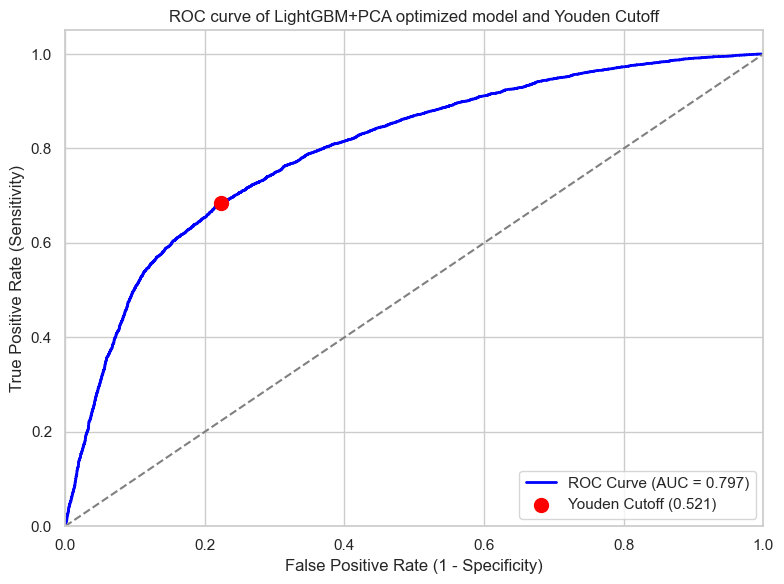

In [ ]:
# ==========================================
# 3. OPTIMIZACIÓN DEL UMBRAL (YOUDEN)
# ==========================================
print("3. Buscando el umbral clínico perfecto (Youden)...")
fpr, tpr, thresholds = roc_curve(y_test, y_lgbm_pca_optimizado)

# Fórmula de Youden's J: Sensibilidad (tpr) - Falsos Positivos (fpr)
j_scores = tpr - fpr
indice_optimo = np.argmax(j_scores)

umbral_youden = thresholds[indice_optimo]
mejor_tpr = tpr[indice_optimo]
mejor_fpr = fpr[indice_optimo]
auc_score = roc_auc_score(y_test, y_lgbm_pca_optimizado)

print(f"\n=== RESULTADOS DE OPTIMIZACIÓN ===")
print(f"AUC Logrado: {auc_score:.4f}")
print(f"Umbral de Youden Óptimo: {umbral_youden:.4f} ({umbral_youden * 100:.2f}%)")

# ==========================================
# 5. GRAFICAR LA CURVA ROC Y EL CODO
# ==========================================
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.scatter(mejor_fpr, mejor_tpr, marker='o', color='red', s=100, label=f'Youden Cutoff ({umbral_youden:.3f})', zorder=5)

plt.title('ROC curve of LightGBM+PCA optimized model and Youden Cutoff')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc="lower right")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig(
    'roc light pca.tiff',
    bbox_inches='tight',
    transparent=False,
    facecolor='white'
)
plt.show()

plt.close()

In [ ]:
### LightGBM + PCA optimized and youden cutoff
# ==========================================
# 3. CREACIÓN Y ENTRENAMIENTO DEL MODELO
# ==========================================
# Instanciar el modelo
modelo_lgbm_pca_opt = LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=12, random_state=42, n_jobs=-1)
auc_score = 0.7970
# Entrenamiento del modelo con los datos de entrenamiento
modelo_lgbm_pca_opt.fit(X_train_pca, y_train)


[LightGBM] [Info] Number of positive: 27871, number of negative: 27908
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003934 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 55779, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499668 -> initscore=-0.001327
[LightGBM] [Info] Start training from score -0.001327


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,12
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:


# ==========================================
# 4. EVALUACIÓN DEL MODELO (CON ENFOQUE YOUDEN)
# ==========================================
# Paso A: En lugar de clases (0 o 1), obtenemos las probabilidades de la clase positiva (enfermo)
y_pca_lgbm_probs_opt = modelo_lgbm_pca_opt.predict_proba(X_test_pca)[:, 1]

# Paso B: Calcular los componentes de la curva ROC y la estadística J de Youden
fpr, tpr, thresholds = roc_curve(y_test, y_pca_lgbm_probs_opt)
j_scores = tpr - fpr
indice_optimo = np.argmax(j_scores)

# Extraemos el umbral de Youden óptimo
umbral_youden = thresholds[indice_optimo]

# Paso C: Generar las nuevas predicciones binarias aplicando el umbral de Youden hallado
y_pca_lgbm_pred_youden = np.where(y_pca_lgbm_probs_opt >= umbral_youden, 1, 0)


# Imprimir las métricas de rendimiento basadas en el umbral optimizado
print(f"=== OPTIMIZACIÓN DE UMBRAL (YOUDEN) ===")
print(f"Umbral Óptimo Encontrado: {umbral_youden:.4f} ({umbral_youden * 100:.2f}%)\n")

print("=== REPORTE DE CLASIFICACIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===")
print(classification_report(y_test, y_pca_lgbm_pred_youden))

print("=== MATRIZ DE CONFUSIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===")
print(confusion_matrix(y_test, y_pca_lgbm_pred_youden))

print(f"\nExactitud General (Accuracy) LightGBM + PCA con Youden: {accuracy_score(y_test, y_pca_lgbm_pred_youden):.4f}")



=== OPTIMIZACIÓN DE UMBRAL (YOUDEN) ===
Umbral Óptimo Encontrado: 0.5163 (51.63%)

=== REPORTE DE CLASIFICACIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===
              precision    recall  f1-score   support

           0       0.71      0.77      0.74      6977
           1       0.75      0.69      0.72      6968

    accuracy                           0.73     13945
   macro avg       0.73      0.73      0.73     13945
weighted avg       0.73      0.73      0.73     13945

=== MATRIZ DE CONFUSIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===
[[5383 1594]
 [2187 4781]]

Exactitud General (Accuracy) LightGBM + PCA con Youden: 0.7289


c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
### PREDICCIÓN SOBRE DATASET B BAJO PCA y LightGBM optimizado
# 1. Usar predict_proba en lugar del clásico predict
probabilidades_lgbm_pca_opt = modelo_lgbm_pca_opt.predict_proba(dfB_escalado_pca)

# 2. Filtramos el arreglo para quedarnos solo con la probabilidad de la clase 1
probabilidades_riesgo_alto_lgbm_pca_opt = probabilidades_lgbm_pca_opt[:, 1]

# 3. Guardar estas probabilidades en el Dataset B original
dfB_con_predicciones_lgbm_pca_opt = dfB.copy() # B dataframe original de 219 pacientes
dfB_con_predicciones_lgbm_pca_opt['high risk probability (%)'] = probabilidades_riesgo_alto_lgbm_pca_opt * 100

# 4. Asignar el dato real de cardio
dfB_con_predicciones_lgbm_pca_opt['real group'] = CardioB

# 5. NUEVA PREDICCIÓN OPTIMIZADA: Aplicamos el Youden Cutoff en escala 100%
# (Asume que 'umbral_youden' viene de la celda de evaluación anterior)
umbral_youden_100 = 0.5214 * 100

dfB_con_predicciones_lgbm_pca_opt['group prediction'] = np.where(
    dfB_con_predicciones_lgbm_pca_opt['high risk probability (%)'] >= umbral_youden_100, 1, 0
)

# Desplegamos las columnas clave para verificar la consistencia del umbral
columnas_revision = ['high risk probability (%)', 'real group', 'group prediction']
dfB_con_predicciones_lgbm_pca_opt[columnas_revision]

,high risk probability (%),real group,group prediction
0,20.923538,0.0,0
1,84.836167,1.0,1
2,81.531937,1.0,1
3,90.349881,1.0,1
4,10.316665,0.0,0
...,...,...,...
214,88.904993,1.0,1
215,82.484629,1.0,1
216,32.591223,1.0,0
217,49.087291,1.0,0


In [ ]:
# 1. Crear columna de comparación booleana (True si acertó, False si falló)
dfB_con_predicciones_lgbm_pca_opt['acierto'] = (
    dfB_con_predicciones_lgbm_pca_opt['real group']
    == dfB_con_predicciones_lgbm_pca_opt['group prediction']
)

# 2. Calcular conteos totales
total_pacientes = len(dfB_con_predicciones_lgbm_pca_opt)
aciertos = dfB_con_predicciones_lgbm_pca_opt['acierto'].sum()
fallos = (~dfB_con_predicciones_lgbm_pca_opt['acierto']).sum()
porcentaje_acierto = (aciertos / total_pacientes) * 100

print("=== RESUMEN GENERAL DE VALIDACIÓN (N = 219) ===")
print(f"Total de pacientes: {total_pacientes}")
print(f"Aciertos:           {aciertos} ({porcentaje_acierto:.2f}%)")
print(f"Fallos:             {fallos} ({100 - porcentaje_acierto:.2f}%)")

=== RESUMEN GENERAL DE VALIDACIÓN (N = 219) ===
Total de pacientes: 219
Aciertos:           157 (71.69%)
Fallos:             62 (28.31%)


In [ ]:
# ==========================================
# 1. DEFINIR LA CUADRÍCULA DE BÚSQUEDA ROC CON LIGHTGBM + umap
# ==========================================
print("1. Iniciando GridSearch optimizando ROC_AUC...")

# Aquí ponemos las combinaciones que queremos que Python pruebe
parametros_grid_lgbm = {
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [6, 8, 10, 12],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

# ==========================================
# 2. INSTANCIAR EL MODELO BASE Y EL GRIDSEARCH
# ==========================================
# Creamos el modelo vacío
lgbm_base = LGBMClassifier(random_state=42)

# Configuramos el motor de búsqueda (GridSearchCV)
grid_search_lgbm = GridSearchCV(
    estimator=lgbm_base,
    param_grid=parametros_grid_lgbm,
    cv=5,                  # Validación cruzada de 5 pliegues
    scoring='roc_auc',    # Métrica a optimizar
    n_jobs=-1,             # Usar todos los procesadores
    verbose=1              # Mostrar progreso en pantalla
)

# ==========================================
# 3. ENTRENAR LA BÚSQUEDA (El proceso pesado)
# ==========================================
print("Iniciando la búsqueda de hiperparámetros. Esto puede tardar varios minutos...")
grid_search_lgbm.fit(X_train_umap, y_train)

# ==========================================
# 4. EXTRAER RESULTADOS Y EVALUAR
# ==========================================
# Guardamos el modelo ganador
mejor_modelo_lgbm_umap = grid_search_lgbm.best_estimator_

# Imprimimos la combinación ganadora
print("\n=== LOS MEJORES HIPERPARÁMETROS SON ===")
print(grid_search_lgbm.best_params_)

# Evaluamos contra nuestros datos de prueba secretos
y_lgbm_umap_optimizado = mejor_modelo_lgbm_umap.predict_proba(X_test_umap)[:, 1]

# ==========================================
# 3. OPTIMIZACIÓN DEL UMBRAL (YOUDEN)
# ==========================================
print("3. Buscando el umbral clínico perfecto (Youden)...")
fpr, tpr, thresholds = roc_curve(y_test, y_lgbm_umap_optimizado)

# Fórmula de Youden's J: Sensibilidad (tpr) - Falsos Positivos (fpr)
j_scores = tpr - fpr
indice_optimo = np.argmax(j_scores)

umbral_youden = thresholds[indice_optimo]
mejor_tpr = tpr[indice_optimo]
mejor_fpr = fpr[indice_optimo]
auc_score = roc_auc_score(y_test, y_lgbm_umap_optimizado)

print(f"\n=== RESULTADOS DE OPTIMIZACIÓN ===")
print(f"AUC Logrado: {auc_score:.4f}")
print(f"Umbral de Youden Óptimo: {umbral_youden:.4f} ({umbral_youden * 100:.2f}%)")



1. Iniciando GridSearch optimizando ROC_AUC...
Iniciando la búsqueda de hiperparámetros. Esto puede tardar varios minutos...
Fitting 5 folds for each of 256 candidates, totalling 1280 fits
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=8. Current value: min_data_in_leaf=8
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=8. Current value: min_data_in_leaf=8
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Info] Number of positive: 27871, number of negative: 27908
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001139 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 55779, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print(f"\n=== RESULTADOS DE OPTIMIZACIÓN ===")
print(f"AUC Logrado: {auc_score:.4f}")
print(f"Umbral de Youden Óptimo: {umbral_youden:.4f} ({umbral_youden * 100:.2f}%)")


=== RESULTADOS DE OPTIMIZACIÓN ===
AUC Logrado: 0.7895
Umbral de Youden Óptimo: 0.5115 (51.15%)


In [ ]:
### LightGBM + UMAP optimized and youden cutoff
# ==========================================
# 3. CREACIÓN Y ENTRENAMIENTO DEL MODELO
# ==========================================
# Instanciar el modelo
modelo_lgbm_umap_opt = LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=10, random_state=42, n_jobs=-1)

# Entrenamiento del modelo con los datos de entrenamiento
modelo_lgbm_umap_opt.fit(X_train_umap, y_train)


[LightGBM] [Info] Number of positive: 27871, number of negative: 27908
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000953 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 55779, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499668 -> initscore=-0.001327
[LightGBM] [Info] Start training from score -0.001327


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,10
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== OPTIMIZACIÓN DE UMBRAL (YOUDEN) ===
Umbral Óptimo Encontrado: 0.5239 (52.39%)

=== REPORTE DE CLASIFICACIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===
              precision    recall  f1-score   support

           0       0.71      0.77      0.74      6977
           1       0.75      0.68      0.71      6968

    accuracy                           0.73     13945
   macro avg       0.73      0.73      0.73     13945
weighted avg       0.73      0.73      0.73     13945

=== MATRIZ DE CONFUSIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===
[[5391 1586]
 [2239 4729]]

Exactitud General (Accuracy) LightGBM + PCA con Youden: 0.7257


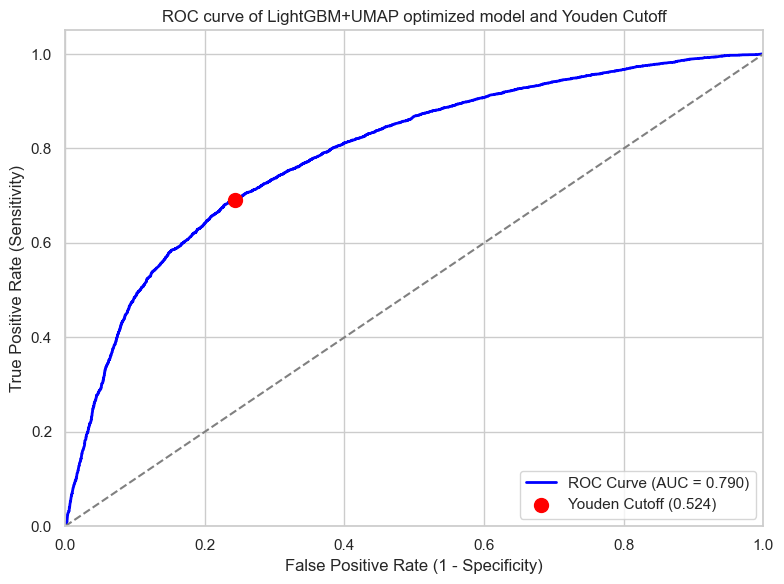

In [ ]:


# ==========================================
# 4. EVALUACIÓN DEL MODELO (CON ENFOQUE YOUDEN)
# ==========================================
# Paso A: En lugar de clases (0 o 1), obtenemos las probabilidades de la clase positiva (enfermo)
y_umap_lgbm_probs_opt = modelo_lgbm_umap_opt.predict_proba(X_test_umap)[:, 1]

# Paso B: Calcular los componentes de la curva ROC y la estadística J de Youden
fpr, tpr, thresholds = roc_curve(y_test, y_umap_lgbm_probs_opt)
j_scores = tpr - fpr
indice_optimo = np.argmax(j_scores)

# Extraemos el umbral de Youden óptimo
umbral_youden = 0.5239

# Paso C: Generar las nuevas predicciones binarias aplicando el umbral de Youden hallado
y_umap_lgbm_pred_youden = np.where(y_umap_lgbm_probs_opt >= umbral_youden, 1, 0)


# Imprimir las métricas de rendimiento basadas en el umbral optimizado
print(f"=== OPTIMIZACIÓN DE UMBRAL (YOUDEN) ===")
print(f"Umbral Óptimo Encontrado: {umbral_youden:.4f} ({umbral_youden * 100:.2f}%)\n")

print("=== REPORTE DE CLASIFICACIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===")
print(classification_report(y_test, y_umap_lgbm_pred_youden))

print("=== MATRIZ DE CONFUSIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===")
print(confusion_matrix(y_test, y_umap_lgbm_pred_youden))

print(f"\nExactitud General (Accuracy) LightGBM + PCA con Youden: {accuracy_score(y_test, y_umap_lgbm_pred_youden):.4f}")

# ==========================================
# 5. GRAFICAR LA CURVA ROC Y EL CODO
# ==========================================
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.scatter(mejor_fpr, mejor_tpr, marker='o', color='red', s=100, label=f'Youden Cutoff ({umbral_youden:.3f})', zorder=5)

plt.title('ROC curve of LightGBM+UMAP optimized model and Youden Cutoff')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc="lower right")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig(
    'roc light umap.tiff',
    bbox_inches='tight',
    transparent=False,
    facecolor='white'
)
plt.show()

plt.close()

In [ ]:
### PREDICCIÓN SOBRE DATASET B BAJO PCA y LightGBM optimizado
# 1. Usar predict_proba en lugar del clásico predict
probabilidades_lgbm_umap_opt = modelo_lgbm_umap_opt.predict_proba(dfB_escalado_umap)

# 2. Filtramos el arreglo para quedarnos solo con la probabilidad de la clase 1
probabilidades_riesgo_alto_lgbm_umap_opt = probabilidades_lgbm_umap_opt[:, 1]

# 3. Guardar estas probabilidades en el Dataset B original
dfB_con_predicciones_lgbm_umap_opt = dfB.copy() # B dataframe original de 219 pacientes
dfB_con_predicciones_lgbm_umap_opt['prob_riesgo_alto (%)'] = probabilidades_riesgo_alto_lgbm_umap_opt * 100

# 4. Asignar el dato real de cardio
dfB_con_predicciones_lgbm_umap_opt['cardio_real'] = CardioB

# 5. NUEVA PREDICCIÓN OPTIMIZADA: Aplicamos el Youden Cutoff en escala 100%
# (Asume que 'umbral_youden' viene de la celda de evaluación anterior)
umbral_youden_100 = 0.5239 * 100

dfB_con_predicciones_lgbm_umap_opt['prediction'] = np.where(
    dfB_con_predicciones_lgbm_umap_opt['prob_riesgo_alto (%)'] >= umbral_youden_100, 1, 0
)

# Desplegamos las columnas clave para verificar la consistencia del umbral
columnas_revision = ['prob_riesgo_alto (%)', 'cardio_real', 'prediction']
dfB_con_predicciones_lgbm_umap_opt[columnas_revision]

,prob_riesgo_alto (%),cardio_real,prediction
0,25.876788,0.0,0
1,85.969823,1.0,1
2,80.344698,1.0,1
3,82.373198,1.0,1
4,24.499616,0.0,0
...,...,...,...
214,83.255121,1.0,1
215,83.933586,1.0,1
216,26.819781,1.0,0
217,34.790133,1.0,0


In [ ]:
# 1. Crear columna de comparación booleana (True si acertó, False si falló)
dfB_con_predicciones_lgbm_umap_opt['acierto'] = (
    dfB_con_predicciones_lgbm_umap_opt['cardio_real']
    == dfB_con_predicciones_lgbm_umap_opt['prediction']
)

# 2. Calcular conteos totales
total_pacientes = len(dfB_con_predicciones_lgbm_umap_opt)
aciertos = dfB_con_predicciones_lgbm_umap_opt['acierto'].sum()
fallos = (~dfB_con_predicciones_lgbm_umap_opt['acierto']).sum()
porcentaje_acierto = (aciertos / total_pacientes) * 100

print("=== RESUMEN GENERAL DE VALIDACIÓN (N = 219) ===")
print(f"Total de pacientes: {total_pacientes}")
print(f"Aciertos:           {aciertos} ({porcentaje_acierto:.2f}%)")
print(f"Fallos:             {fallos} ({100 - porcentaje_acierto:.2f}%)")

=== RESUMEN GENERAL DE VALIDACIÓN (N = 219) ===
Total de pacientes: 219
Aciertos:           157 (71.69%)
Fallos:             62 (28.31%)


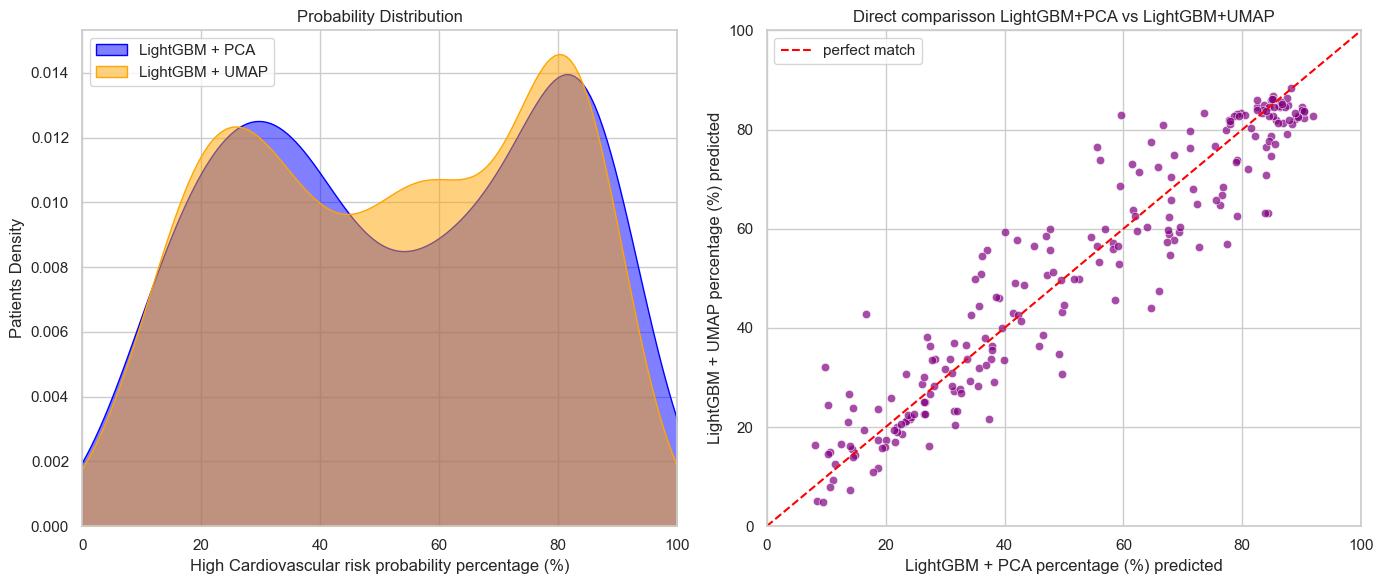

In [ ]:
# Extraer las probabilidades de ambas tablas (asumiendo que la columna se llama 'prob_riesgo_alto (%)')

prob_lgbm_pca = dfB_con_predicciones_lgbm_pca_opt['high risk probability (%)']
prob_lgbm_umap = dfB_con_predicciones_lgbm_umap_opt['prob_riesgo_alto (%)']

# Usamos seaborn para darle un estilo moderno y limpio con cuadrícula
sns.set_theme(style="whitegrid")
# Crear una figura con 1 fila y 2 columnas para poner los gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================
# 3. GRÁFICA 1: DISTRIBUCIÓN DE PROBABILIDADES
# ==========================================
# ax=axes[0] indica que va en el lado izquierdo. fill=True rellena el área de color.
sns.kdeplot(prob_lgbm_pca, fill=True, color="blue", label="LightGBM + PCA", ax=axes[0], alpha=0.5)
sns.kdeplot(prob_lgbm_umap, fill=True, color="orange", label="LightGBM + UMAP", ax=axes[0], alpha=0.5)

axes[0].set_title('Probability Distribution')
axes[0].set_xlabel('High Cardiovascular risk probability percentage (%)')
axes[0].set_ylabel('Patients Density')
axes[0].set_xlim(0, 100) # Fijar el límite del eje X de 0 a 100
axes[0].legend()

# ==========================================
# 4. GRÁFICA 2: COMPARACIÓN PACIENTE POR PACIENTE
# ==========================================
# ax=axes[1] indica que va en el lado derecho. Cada punto es un paciente.
sns.scatterplot(x=prob_lgbm_pca, y=prob_lgbm_umap, alpha=0.7, color="purple", ax=axes[1])

# Dibujamos una línea diagonal roja perfecta (si y=x)
# Si un punto cae en esta línea, significa que PCA y UMAP dieron exactamente el mismo %
axes[1].plot([0, 100], [0, 100], color='red', linestyle='--', label='perfect match')

axes[1].set_title('Direct comparisson LightGBM+PCA vs LightGBM+UMAP')
axes[1].set_xlabel('LightGBM + PCA percentage (%) predicted')
axes[1].set_ylabel('LightGBM + UMAP percentage (%) predicted')
axes[1].set_xlim(0, 100) # Ejes de 0 a 100
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.savefig(
    'comparison light pca umap.tiff',
    bbox_inches='tight',
    transparent=False,
    facecolor='white'
)
plt.show()

plt.close()

In [ ]:
# ==========================================
# 1. DEFINIR LA CUADRÍCULA DE BÚSQUEDA ROC CON XGBoost + PCA
# ==========================================
print("1. Iniciando GridSearch optimizando ROC_AUC...")

# Aquí ponemos las combinaciones que queremos que Python pruebe
parametros_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# ==========================================
# 2. INSTANCIAR EL MODELO BASE Y EL GRIDSEARCH
# ==========================================
# Creamos el modelo vacío
xgb_base = xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')

# Configuramos el motor de búsqueda (GridSearchCV)
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=parametros_grid_xgb,
    cv=5,
    scoring='roc_auc',  # Optimizamos el área bajo la curva
    n_jobs=-1,
    verbose=1
)

# ==========================================
# 3. ENTRENAR LA BÚSQUEDA (El proceso pesado)
# ==========================================
print("Iniciando la búsqueda de hiperparámetros. Esto puede tardar varios minutos...")
grid_search_xgb.fit(X_train_pca, y_train)

# ==========================================
# 4. EXTRAER RESULTADOS Y EVALUAR
# ==========================================
# Guardamos el modelo ganador
mejor_modelo_xgb_pca = grid_search_xgb.best_estimator_

# Imprimimos la combinación ganadora
print("\n=== LOS MEJORES HIPERPARÁMETROS SON ===")
print(grid_search_xgb.best_params_)

# Evaluamos contra nuestros datos de prueba secretos
y_xgb_pca_optimizado = mejor_modelo_xgb_pca.predict_proba(X_test_pca)[:, 1]

# ==========================================
# 3. OPTIMIZACIÓN DEL UMBRAL (YOUDEN)
# ==========================================
print("3. Buscando el umbral clínico perfecto (Youden)...")
fpr, tpr, thresholds = roc_curve(y_test, y_xgb_pca_optimizado)

# Fórmula de Youden's J: Sensibilidad (tpr) - Falsos Positivos (fpr)
j_scores = tpr - fpr
indice_optimo = np.argmax(j_scores)

umbral_youden = thresholds[indice_optimo]
mejor_tpr = tpr[indice_optimo]
mejor_fpr = fpr[indice_optimo]
auc_score = roc_auc_score(y_test, y_xgb_pca_optimizado)

print(f"\n=== RESULTADOS DE OPTIMIZACIÓN ===")
print(f"AUC Logrado: {auc_score:.4f}")
print(f"Umbral de Youden Óptimo: {umbral_youden:.4f} ({umbral_youden * 100:.2f}%)")



1. Iniciando GridSearch optimizando ROC_AUC...
Iniciando la búsqueda de hiperparámetros. Esto puede tardar varios minutos...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

=== LOS MEJORES HIPERPARÁMETROS SON ===
{'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
3. Buscando el umbral clínico perfecto (Youden)...

=== RESULTADOS DE OPTIMIZACIÓN ===
AUC Logrado: 0.7977
Umbral de Youden Óptimo: 0.5268 (52.68%)


In [ ]:
### XGBoost + PCA optimized and youden cutoff
# ==========================================
# 3. CREACIÓN Y ENTRENAMIENTO DEL MODELO
# ==========================================
# Instanciar el modelo
modelo_xgb_pca_opt = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)

# Entrenamiento del modelo con los datos de entrenamiento
modelo_xgb_pca_opt.fit(X_train_pca, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

=== OPTIMIZACIÓN DE UMBRAL (YOUDEN) ===
Umbral Óptimo Encontrado: 0.5268 (52.68%)

=== REPORTE DE CLASIFICACIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===
              precision    recall  f1-score   support

           0       0.71      0.78      0.74      6977
           1       0.76      0.67      0.71      6968

    accuracy                           0.73     13945
   macro avg       0.73      0.73      0.73     13945
weighted avg       0.73      0.73      0.73     13945

=== MATRIZ DE CONFUSIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===
[[5455 1522]
 [2268 4700]]

Exactitud General (Accuracy) LightGBM + PCA con Youden: 0.7282


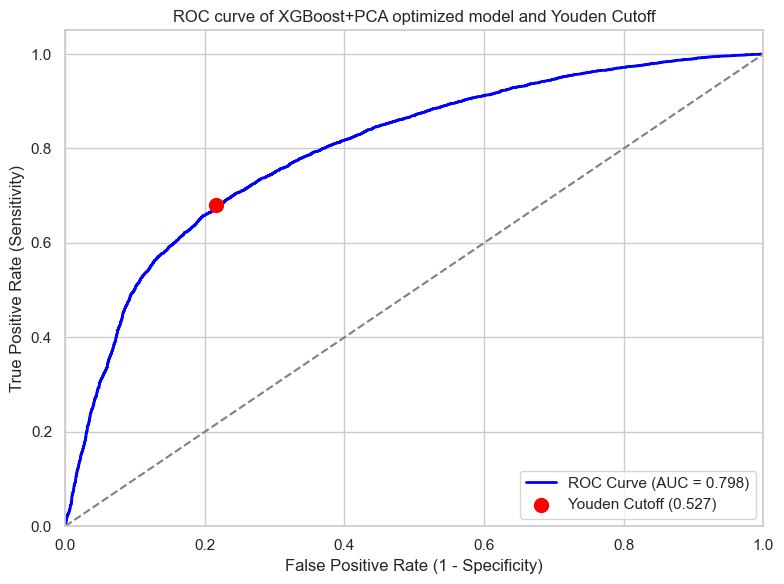

In [ ]:



# ==========================================
# 4. EVALUACIÓN DEL MODELO (CON ENFOQUE YOUDEN)
# ==========================================
# Paso A: En lugar de clases (0 o 1), obtenemos las probabilidades de la clase positiva (enfermo)
y_pca_xgb_probs_opt = modelo_xgb_pca_opt.predict_proba(X_test_pca)[:, 1]

# Paso B: Calcular los componentes de la curva ROC y la estadística J de Youden
fpr, tpr, thresholds = roc_curve(y_test, y_pca_xgb_probs_opt)
j_scores = tpr - fpr
indice_optimo = np.argmax(j_scores)

# Extraemos el umbral de Youden óptimo
#umbral_youden = thresholds[indice_optimo]

# Paso C: Generar las nuevas predicciones binarias aplicando el umbral de Youden hallado
y_pca_xgb_pred_youden = np.where(y_pca_xgb_probs_opt >= umbral_youden, 1, 0)


# Imprimir las métricas de rendimiento basadas en el umbral optimizado
print(f"=== OPTIMIZACIÓN DE UMBRAL (YOUDEN) ===")
print(f"Umbral Óptimo Encontrado: {umbral_youden:.4f} ({umbral_youden * 100:.2f}%)\n")

print("=== REPORTE DE CLASIFICACIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===")
print(classification_report(y_test, y_pca_xgb_pred_youden))

print("=== MATRIZ DE CONFUSIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===")
print(confusion_matrix(y_test, y_pca_xgb_pred_youden))

print(f"\nExactitud General (Accuracy) LightGBM + PCA con Youden: {accuracy_score(y_test, y_pca_xgb_pred_youden):.4f}")

# ==========================================
# 5. GRAFICAR LA CURVA ROC Y EL CODO
# ==========================================
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.scatter(mejor_fpr, mejor_tpr, marker='o', color='red', s=100, label=f'Youden Cutoff ({umbral_youden:.3f})', zorder=5)

plt.title('ROC curve of XGBoost+PCA optimized model and Youden Cutoff')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc="lower right")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig(
    'roc xgb pca.tiff',
    bbox_inches='tight',
    transparent=False,
    facecolor='white'
)
plt.show()

plt.close()

In [ ]:
### PREDICCIÓN SOBRE DATASET B BAJO PCA y XGBoost optimizado
# 1. Usar predict_proba en lugar del clásico predict
probabilidades_xgb_pca_opt = modelo_xgb_pca_opt.predict_proba(dfB_escalado_pca)

# 2. Filtramos el arreglo para quedarnos solo con la probabilidad de la clase 1
probabilidades_riesgo_alto_xgb_pca_opt = probabilidades_xgb_pca_opt[:, 1]

# 3. Guardar estas probabilidades en el Dataset B original
dfB_con_predicciones_xgb_pca_opt = dfB.copy() # B dataframe original de 219 pacientes
dfB_con_predicciones_xgb_pca_opt['prob_riesgo_alto (%)'] = probabilidades_riesgo_alto_xgb_pca_opt * 100

# 4. Asignar el dato real de cardio
dfB_con_predicciones_xgb_pca_opt['cardio_real'] = CardioB

# 5. NUEVA PREDICCIÓN OPTIMIZADA: Aplicamos el Youden Cutoff en escala 100%
# (Asume que 'umbral_youden' viene de la celda de evaluación anterior)
umbral_youden_100 = 0.5027 * 100

dfB_con_predicciones_xgb_pca_opt['prediction'] = np.where(
    dfB_con_predicciones_xgb_pca_opt['prob_riesgo_alto (%)'] >= umbral_youden_100, 1, 0
)

# Desplegamos las columnas clave para verificar la consistencia del umbral
columnas_revision = ['prob_riesgo_alto (%)', 'cardio_real', 'prediction']
dfB_con_predicciones_xgb_pca_opt[columnas_revision]

,prob_riesgo_alto (%),cardio_real,prediction
0,24.463253,0.0,0
1,84.697495,1.0,1
2,76.246353,1.0,1
3,90.275833,1.0,1
4,9.931591,0.0,0
...,...,...,...
214,89.447502,1.0,1
215,81.056557,1.0,1
216,36.732891,1.0,0
217,49.220451,1.0,0


In [ ]:
# 1. Crear columna de comparación booleana (True si acertó, False si falló)
dfB_con_predicciones_xgb_pca_opt['acierto'] = (
    dfB_con_predicciones_xgb_pca_opt['cardio_real']
    == dfB_con_predicciones_xgb_pca_opt['prediction']
)

# 2. Calcular conteos totales
total_pacientes = len(dfB_con_predicciones_xgb_pca_opt)
aciertos = dfB_con_predicciones_xgb_pca_opt['acierto'].sum()
fallos = (~dfB_con_predicciones_xgb_pca_opt['acierto']).sum()
porcentaje_acierto = (aciertos / total_pacientes) * 100

print("=== RESUMEN GENERAL DE VALIDACIÓN (N = 219) ===")
print(f"Total de pacientes: {total_pacientes}")
print(f"Aciertos:           {aciertos} ({porcentaje_acierto:.2f}%)")
print(f"Fallos:             {fallos} ({100 - porcentaje_acierto:.2f}%)")

=== RESUMEN GENERAL DE VALIDACIÓN (N = 219) ===
Total de pacientes: 219
Aciertos:           159 (72.60%)
Fallos:             60 (27.40%)


In [ ]:
# ==========================================
# 1. DEFINIR LA CUADRÍCULA DE BÚSQUEDA ROC CON XGBoost + UMAP
# ==========================================
print("1. Iniciando GridSearch optimizando ROC_AUC...")

# Aquí ponemos las combinaciones que queremos que Python pruebe
parametros_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# ==========================================
# 2. INSTANCIAR EL MODELO BASE Y EL GRIDSEARCH
# ==========================================
# Creamos el modelo vacío
xgb_base = xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')

# Configuramos el motor de búsqueda (GridSearchCV)
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=parametros_grid_xgb,
    cv=5,
    scoring='roc_auc',  # Optimizamos el área bajo la curva
    n_jobs=-1,
    verbose=1
)

# ==========================================
# 3. ENTRENAR LA BÚSQUEDA (El proceso pesado)
# ==========================================
print("Iniciando la búsqueda de hiperparámetros. Esto puede tardar varios minutos...")
grid_search_xgb.fit(X_train_umap, y_train)

# ==========================================
# 4. EXTRAER RESULTADOS Y EVALUAR
# ==========================================
# Guardamos el modelo ganador
mejor_modelo_xgb_umap = grid_search_xgb.best_estimator_

# Imprimimos la combinación ganadora
print("\n=== LOS MEJORES HIPERPARÁMETROS SON ===")
print(grid_search_xgb.best_params_)

# Evaluamos contra nuestros datos de prueba secretos
y_xgb_umap_optimizado = mejor_modelo_xgb_umap.predict_proba(X_test_umap)[:, 1]

# ==========================================
# 3. OPTIMIZACIÓN DEL UMBRAL (YOUDEN)
# ==========================================
print("3. Buscando el umbral clínico perfecto (Youden)...")
fpr, tpr, thresholds = roc_curve(y_test, y_xgb_umap_optimizado)

# Fórmula de Youden's J: Sensibilidad (tpr) - Falsos Positivos (fpr)
j_scores = tpr - fpr
indice_optimo = np.argmax(j_scores)

umbral_youden = thresholds[indice_optimo]
mejor_tpr = tpr[indice_optimo]
mejor_fpr = fpr[indice_optimo]
auc_score = roc_auc_score(y_test, y_xgb_umap_optimizado)

print(f"\n=== RESULTADOS DE OPTIMIZACIÓN ===")
print(f"AUC Logrado: {auc_score:.4f}")
print(f"Umbral de Youden Óptimo: {umbral_youden:.4f} ({umbral_youden * 100:.2f}%)")



1. Iniciando GridSearch optimizando ROC_AUC...
Iniciando la búsqueda de hiperparámetros. Esto puede tardar varios minutos...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

=== LOS MEJORES HIPERPARÁMETROS SON ===
{'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
3. Buscando el umbral clínico perfecto (Youden)...

=== RESULTADOS DE OPTIMIZACIÓN ===
AUC Logrado: 0.7902
Umbral de Youden Óptimo: 0.5383 (53.83%)


In [ ]:
### XGBoost + umap optimized and youden cutoff
# ==========================================
# 3. CREACIÓN Y ENTRENAMIENTO DEL MODELO
# ==========================================
# Instanciar el modelo
modelo_xgb_umap_opt = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)

# Entrenamiento del modelo con los datos de entrenamiento
modelo_xgb_umap_opt.fit(X_train_umap, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

=== OPTIMIZACIÓN DE UMBRAL (YOUDEN) ===
Umbral Óptimo Encontrado: 0.4958 (49.58%)

=== REPORTE DE CLASIFICACIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===
              precision    recall  f1-score   support

           0       0.71      0.74      0.72      6977
           1       0.73      0.70      0.71      6968

    accuracy                           0.72     13945
   macro avg       0.72      0.72      0.72     13945
weighted avg       0.72      0.72      0.72     13945

=== MATRIZ DE CONFUSIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===
[[5143 1834]
 [2076 4892]]

Exactitud General (Accuracy) xgboost + umap con Youden: 0.7196


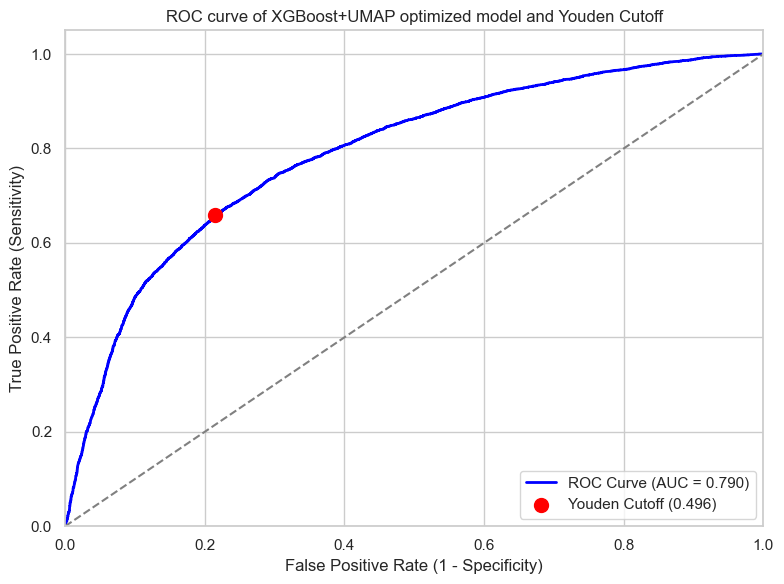

In [ ]:


# ==========================================
# 4. EVALUACIÓN DEL MODELO (CON ENFOQUE YOUDEN)
# ==========================================
# Paso A: En lugar de clases (0 o 1), obtenemos las probabilidades de la clase positiva (enfermo)
y_umap_xgb_probs_opt = modelo_xgb_umap_opt.predict_proba(X_test_umap)[:, 1]

# Paso B: Calcular los componentes de la curva ROC y la estadística J de Youden
fpr, tpr, thresholds = roc_curve(y_test, y_umap_xgb_probs_opt)
j_scores = tpr - fpr
indice_optimo = np.argmax(j_scores)

# Extraemos el umbral de Youden óptimo
umbral_youden = 0.4958

# Paso C: Generar las nuevas predicciones binarias aplicando el umbral de Youden hallado
y_umap_xgb_pred_youden = np.where(y_umap_xgb_probs_opt >= umbral_youden, 1, 0)


# Imprimir las métricas de rendimiento basadas en el umbral optimizado
print(f"=== OPTIMIZACIÓN DE UMBRAL (YOUDEN) ===")
print(f"Umbral Óptimo Encontrado: {umbral_youden:.4f} ({umbral_youden * 100:.2f}%)\n")

print("=== REPORTE DE CLASIFICACIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===")
print(classification_report(y_test, y_umap_xgb_pred_youden))

print("=== MATRIZ DE CONFUSIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===")
print(confusion_matrix(y_test, y_umap_xgb_pred_youden))

print(f"\nExactitud General (Accuracy) xgboost + umap con Youden: {accuracy_score(y_test, y_umap_xgb_pred_youden):.4f}")

# ==========================================
# 5. GRAFICAR LA CURVA ROC Y EL CODO
# ==========================================
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.scatter(mejor_fpr, mejor_tpr, marker='o', color='red', s=100, label=f'Youden Cutoff ({umbral_youden:.3f})', zorder=5)

plt.title('ROC curve of XGBoost+UMAP optimized model and Youden Cutoff')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc="lower right")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig(
    'roc xgb umap.tiff',
    bbox_inches='tight',
    transparent=False,
    facecolor='white'
)
plt.show()

plt.close()

In [ ]:
### PREDICCIÓN SOBRE DATASET B BAJO UMAP y XGBoost optimizado
# 1. Usar predict_proba en lugar del clásico predict
probabilidades_xgb_umap_opt = modelo_xgb_umap_opt.predict_proba(dfB_escalado_umap)

# 2. Filtramos el arreglo para quedarnos solo con la probabilidad de la clase 1
probabilidades_riesgo_alto_xgb_umap_opt = probabilidades_xgb_umap_opt[:, 1]

# 3. Guardar estas probabilidades en el Dataset B original
dfB_con_predicciones_xgb_umap_opt = dfB.copy() # B dataframe original de 219 pacientes
dfB_con_predicciones_xgb_umap_opt['prob_riesgo_alto (%)'] = probabilidades_riesgo_alto_xgb_umap_opt * 100

# 4. Asignar el dato real de cardio
dfB_con_predicciones_xgb_umap_opt['cardio_real'] = CardioB

# 5. NUEVA PREDICCIÓN OPTIMIZADA: Aplicamos el Youden Cutoff en escala 100%
# (Asume que 'umbral_youden' viene de la celda de evaluación anterior)
umbral_youden_100 = 0.4958 * 100

dfB_con_predicciones_xgb_umap_opt['prediction'] = np.where(
    dfB_con_predicciones_xgb_umap_opt['prob_riesgo_alto (%)'] >= umbral_youden_100, 1, 0
)

# Desplegamos las columnas clave para verificar la consistencia del umbral
columnas_revision = ['prob_riesgo_alto (%)', 'cardio_real', 'prediction']
dfB_con_predicciones_xgb_umap_opt[columnas_revision]

,prob_riesgo_alto (%),cardio_real,prediction
0,26.416254,0.0,0
1,85.140923,1.0,1
2,78.185928,1.0,1
3,83.070251,1.0,1
4,12.900058,0.0,0
...,...,...,...
214,86.572098,1.0,1
215,82.953133,1.0,1
216,26.387648,1.0,0
217,34.579479,1.0,0


In [ ]:
# 1. Crear columna de comparación booleana (True si acertó, False si falló)
dfB_con_predicciones_xgb_umap_opt['acierto'] = (
    dfB_con_predicciones_xgb_umap_opt['cardio_real']
    == dfB_con_predicciones_xgb_umap_opt['prediction']
)

# 2. Calcular conteos totales
total_pacientes = len(dfB_con_predicciones_xgb_umap_opt)
aciertos = dfB_con_predicciones_xgb_umap_opt['acierto'].sum()
fallos = (~dfB_con_predicciones_xgb_umap_opt['acierto']).sum()
porcentaje_acierto = (aciertos / total_pacientes) * 100

print("=== RESUMEN GENERAL DE VALIDACIÓN (N = 219) ===")
print(f"Total de pacientes: {total_pacientes}")
print(f"Aciertos:           {aciertos} ({porcentaje_acierto:.2f}%)")
print(f"Fallos:             {fallos} ({100 - porcentaje_acierto:.2f}%)")

=== RESUMEN GENERAL DE VALIDACIÓN (N = 219) ===
Total de pacientes: 219
Aciertos:           156 (71.23%)
Fallos:             63 (28.77%)


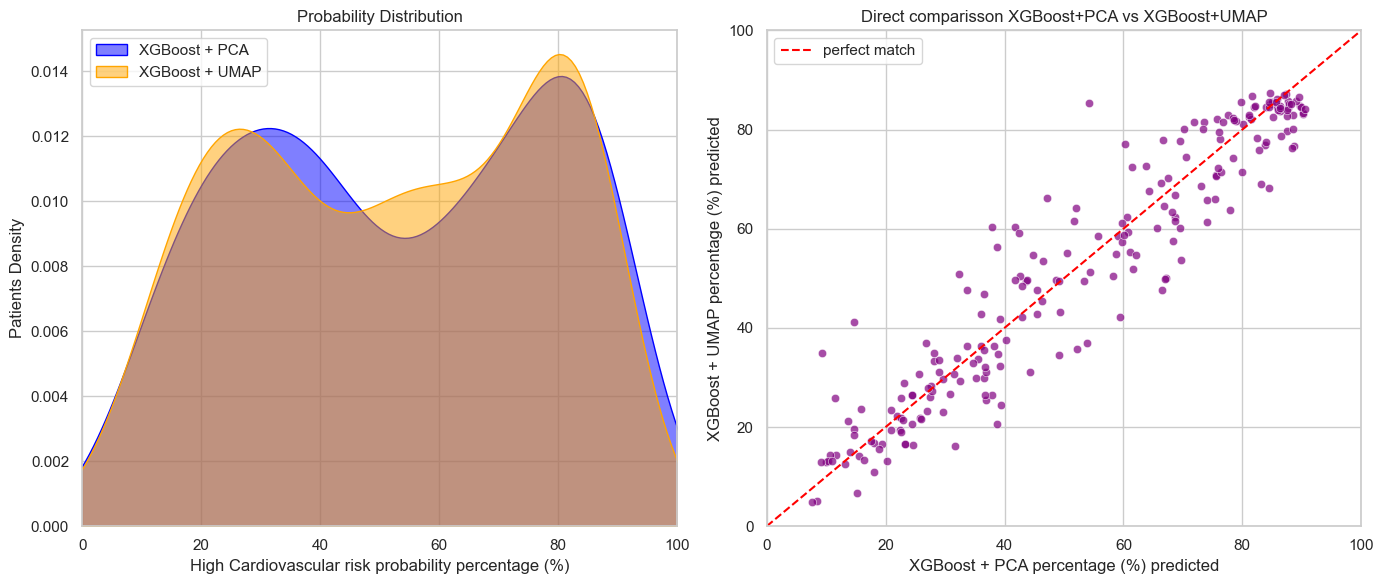

In [ ]:
# Extraer las probabilidades de ambas tablas (asumiendo que la columna se llama 'prob_riesgo_alto (%)')

prob_xgb_pca = dfB_con_predicciones_xgb_pca_opt['prob_riesgo_alto (%)']
prob_xgb_umap = dfB_con_predicciones_xgb_umap_opt['prob_riesgo_alto (%)']

# Usamos seaborn para darle un estilo moderno y limpio con cuadrícula
sns.set_theme(style="whitegrid")
# Crear una figura con 1 fila y 2 columnas para poner los gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================
# 3. GRÁFICA 1: DISTRIBUCIÓN DE PROBABILIDADES
# ==========================================
# ax=axes[0] indica que va en el lado izquierdo. fill=True rellena el área de color.
sns.kdeplot(prob_xgb_pca, fill=True, color="blue", label="XGBoost + PCA", ax=axes[0], alpha=0.5)
sns.kdeplot(prob_xgb_umap, fill=True, color="orange", label="XGBoost + UMAP", ax=axes[0], alpha=0.5)

axes[0].set_title('Probability Distribution')
axes[0].set_xlabel('High Cardiovascular risk probability percentage (%)')
axes[0].set_ylabel('Patients Density')
axes[0].set_xlim(0, 100) # Fijar el límite del eje X de 0 a 100
axes[0].legend()

# ==========================================
# 4. GRÁFICA 2: COMPARACIÓN PACIENTE POR PACIENTE
# ==========================================
# ax=axes[1] indica que va en el lado derecho. Cada punto es un paciente.
sns.scatterplot(x=prob_xgb_pca, y=prob_xgb_umap, alpha=0.7, color="purple", ax=axes[1])

# Dibujamos una línea diagonal roja perfecta (si y=x)
# Si un punto cae en esta línea, significa que PCA y UMAP dieron exactamente el mismo %
axes[1].plot([0, 100], [0, 100], color='red', linestyle='--', label='perfect match')

axes[1].set_title('Direct comparisson XGBoost+PCA vs XGBoost+UMAP')
axes[1].set_xlabel('XGBoost + PCA percentage (%) predicted')
axes[1].set_ylabel('XGBoost + UMAP percentage (%) predicted')
axes[1].set_xlim(0, 100) # Ejes de 0 a 100
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.savefig(
    'comparisson xgb pca umap.tiff',
    bbox_inches='tight',
    transparent=False,
    facecolor='white'
)
plt.show()

plt.close()

In [ ]:
# ==========================================
# 1. DEFINIR LA CUADRÍCULA DE BÚSQUEDA ROC CON RF + PCA
# ==========================================
# Aquí ponemos las combinaciones que queremos que Python pruebe
parametros_grid_rf = {
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [6, 8, 10, 12],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# ==========================================
# 2. INSTANCIAR EL MODELO BASE Y EL GRIDSEARCH
# ==========================================
# Creamos el modelo vacío
rf_base = RandomForestClassifier(random_state=42)

# Configuramos el motor de búsqueda (GridSearchCV)
grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=parametros_grid_rf,
    cv=5,                  # Validación cruzada de 5 pliegues
    scoring='roc_auc',    # Métrica a optimizar
    n_jobs=-1,             # Usar todos los procesadores
    verbose=2              # Mostrar progreso en pantalla
)

# ==========================================
# 3. ENTRENAR LA BÚSQUEDA (El proceso pesado)
# ==========================================
print("Iniciando la búsqueda de hiperparámetros. Esto puede tardar varios minutos...")
grid_search_rf.fit(X_train_pca, y_train)

# ==========================================
# 4. EXTRAER RESULTADOS Y EVALUAR
# ==========================================
# Guardamos el modelo ganador
mejor_modelo_rf_pca = grid_search_rf.best_estimator_

# Imprimimos la combinación ganadora
print("\n=== LOS MEJORES HIPERPARÁMETROS SON ===")
print(grid_search_rf.best_params_)

# Evaluamos contra nuestros datos de prueba secretos
y_rf_pca_optimizado = mejor_modelo_rf_pca.predict_proba(X_test_pca)[:, 1]

# ==========================================
# 3. OPTIMIZACIÓN DEL UMBRAL (YOUDEN)
# ==========================================
print("3. Buscando el umbral clínico perfecto (Youden)...")
fpr, tpr, thresholds = roc_curve(y_test, y_rf_pca_optimizado)

# Fórmula de Youden's J: Sensibilidad (tpr) - Falsos Positivos (fpr)
j_scores = tpr - fpr
indice_optimo = np.argmax(j_scores)

umbral_youden = thresholds[indice_optimo]
mejor_tpr = tpr[indice_optimo]
mejor_fpr = fpr[indice_optimo]
auc_score = roc_auc_score(y_test, y_rf_pca_optimizado)

print(f"\n=== RESULTADOS DE OPTIMIZACIÓN ===")
print(f"AUC Logrado: {auc_score:.4f}")
print(f"Umbral de Youden Óptimo: {umbral_youden:.4f} ({umbral_youden * 100:.2f}%)")

Iniciando la búsqueda de hiperparámetros. Esto puede tardar varios minutos...
Fitting 5 folds for each of 144 candidates, totalling 720 fits

=== LOS MEJORES HIPERPARÁMETROS SON ===
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 250}
3. Buscando el umbral clínico perfecto (Youden)...

=== RESULTADOS DE OPTIMIZACIÓN ===
AUC Logrado: 0.7978
Umbral de Youden Óptimo: 0.5081 (50.81%)


In [ ]:
### RF + PCA optimized and youden cutoff
# ==========================================
# 3. CREACIÓN Y ENTRENAMIENTO DEL MODELO
# ==========================================
# Instanciar el modelo
modelo_rf_pca_opt = RandomForestClassifier(n_estimators=250, max_depth=10, random_state=42, n_jobs=-1, min_samples_leaf=4, min_samples_split=2)

# Entrenamiento del modelo con los datos de entrenamiento
modelo_rf_pca_opt.fit(X_train_pca, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

=== OPTIMIZACIÓN DE UMBRAL (YOUDEN) ===
Umbral Óptimo Encontrado: 0.5186 (51.86%)

=== REPORTE DE CLASIFICACIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===
              precision    recall  f1-score   support

           0       0.72      0.77      0.74      6977
           1       0.75      0.69      0.72      6968

    accuracy                           0.73     13945
   macro avg       0.73      0.73      0.73     13945
weighted avg       0.73      0.73      0.73     13945

=== MATRIZ DE CONFUSIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===
[[5362 1615]
 [2132 4836]]

Exactitud General (Accuracy) LightGBM + PCA con Youden: 0.7313


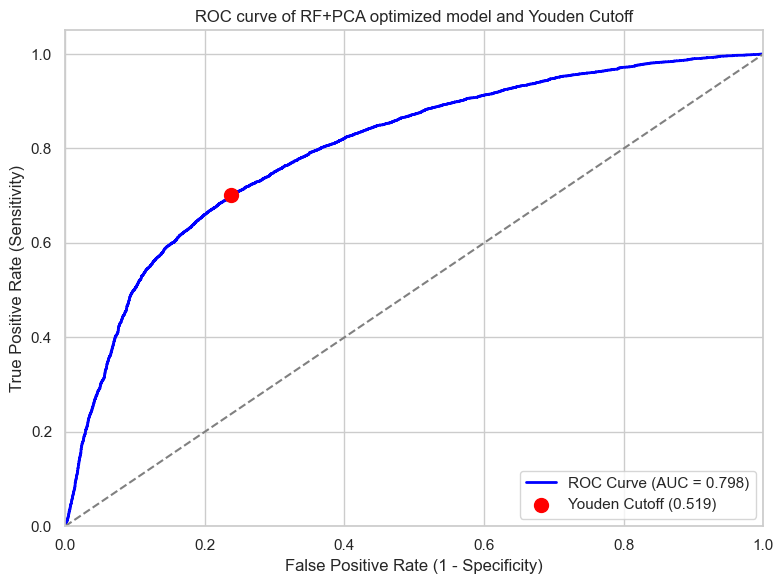

In [ ]:

# ==========================================
# 4. EVALUACIÓN DEL MODELO (CON ENFOQUE YOUDEN)
# ==========================================
# Paso A: En lugar de clases (0 o 1), obtenemos las probabilidades de la clase positiva (enfermo)
y_pca_rf_probs_opt = modelo_rf_pca_opt.predict_proba(X_test_pca)[:, 1]

# Paso B: Calcular los componentes de la curva ROC y la estadística J de Youden
fpr, tpr, thresholds = roc_curve(y_test, y_pca_rf_probs_opt)
j_scores = tpr - fpr
indice_optimo = np.argmax(j_scores)

# Extraemos el umbral de Youden óptimo
umbral_youden = thresholds[indice_optimo]

# Paso C: Generar las nuevas predicciones binarias aplicando el umbral de Youden hallado
y_pca_rf_pred_youden = np.where(y_pca_rf_probs_opt >= umbral_youden, 1, 0)


# Imprimir las métricas de rendimiento basadas en el umbral optimizado
print(f"=== OPTIMIZACIÓN DE UMBRAL (YOUDEN) ===")
print(f"Umbral Óptimo Encontrado: {umbral_youden:.4f} ({umbral_youden * 100:.2f}%)\n")

print("=== REPORTE DE CLASIFICACIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===")
print(classification_report(y_test, y_pca_rf_pred_youden))

print("=== MATRIZ DE CONFUSIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===")
print(confusion_matrix(y_test, y_pca_rf_pred_youden))

print(f"\nExactitud General (Accuracy) LightGBM + PCA con Youden: {accuracy_score(y_test, y_pca_rf_pred_youden):.4f}")

# ==========================================
# 5. GRAFICAR LA CURVA ROC Y EL CODO
# ==========================================
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.scatter(mejor_fpr, mejor_tpr, marker='o', color='red', s=100, label=f'Youden Cutoff ({umbral_youden:.3f})', zorder=5)

plt.title('ROC curve of RF+PCA optimized model and Youden Cutoff')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc="lower right")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig(
    'roc rf pca.tiff',
    bbox_inches='tight',
    transparent=False,
    facecolor='white'
)
plt.show()

plt.close()

In [ ]:
### PREDICCIÓN SOBRE DATASET B BAJO PCA y RF optimizado
# 1. Usar predict_proba en lugar del clásico predict
probabilidades_rf_pca_opt = modelo_rf_pca_opt.predict_proba(dfB_escalado_pca)

# 2. Filtramos el arreglo para quedarnos solo con la probabilidad de la clase 1
probabilidades_riesgo_alto_rf_pca_opt = probabilidades_rf_pca_opt[:, 1]

# 3. Guardar estas probabilidades en el Dataset B original
dfB_con_predicciones_rf_pca_opt = dfB.copy() # B dataframe original de 219 pacientes
dfB_con_predicciones_rf_pca_opt['prob_riesgo_alto (%)'] = probabilidades_riesgo_alto_rf_pca_opt * 100

# 4. Asignar el dato real de cardio
dfB_con_predicciones_rf_pca_opt['cardio_real'] = CardioB

# 5. NUEVA PREDICCIÓN OPTIMIZADA: Aplicamos el Youden Cutoff en escala 100%
# (Asume que 'umbral_youden' viene de la celda de evaluación anterior)
umbral_youden_100 = 0.5186 * 100

dfB_con_predicciones_rf_pca_opt['prediction'] = np.where(
    dfB_con_predicciones_rf_pca_opt['prob_riesgo_alto (%)'] >= umbral_youden_100, 1, 0
)

# Desplegamos las columnas clave para verificar la consistencia del umbral
columnas_revision = ['prob_riesgo_alto (%)', 'cardio_real', 'prediction']
dfB_con_predicciones_rf_pca_opt[columnas_revision]

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


,prob_riesgo_alto (%),cardio_real,prediction
0,20.711868,0.0,0
1,82.691653,1.0,1
2,74.923214,1.0,1
3,87.272131,1.0,1
4,9.602858,0.0,0
...,...,...,...
214,89.685150,1.0,1
215,81.124567,1.0,1
216,34.113943,1.0,0
217,45.612702,1.0,0


In [ ]:
# 1. Crear columna de comparación booleana (True si acertó, False si falló)
dfB_con_predicciones_rf_pca_opt['acierto'] = (
    dfB_con_predicciones_rf_pca_opt['cardio_real']
    == dfB_con_predicciones_rf_pca_opt['prediction']
)

# 2. Calcular conteos totales
total_pacientes = len(dfB_con_predicciones_rf_pca_opt)
aciertos = dfB_con_predicciones_rf_pca_opt['acierto'].sum()
fallos = (~dfB_con_predicciones_rf_pca_opt['acierto']).sum()
porcentaje_acierto = (aciertos / total_pacientes) * 100

print("=== RESUMEN GENERAL DE VALIDACIÓN (N = 219) ===")
print(f"Total de pacientes: {total_pacientes}")
print(f"Aciertos:           {aciertos} ({porcentaje_acierto:.2f}%)")
print(f"Fallos:             {fallos} ({100 - porcentaje_acierto:.2f}%)")

=== RESUMEN GENERAL DE VALIDACIÓN (N = 219) ===
Total de pacientes: 219
Aciertos:           161 (73.52%)
Fallos:             58 (26.48%)


In [ ]:
# ==========================================
# 1. DEFINIR LA CUADRÍCULA DE BÚSQUEDA ROC CON RF + UMAP
# ==========================================

# ==========================================
# 3. ENTRENAR LA BÚSQUEDA (El proceso pesado)
# ==========================================
print("Iniciando la búsqueda de hiperparámetros. Esto puede tardar varios minutos...")
grid_search_rf.fit(X_train_umap, y_train)

# ==========================================
# 4. EXTRAER RESULTADOS Y EVALUAR
# ==========================================
# Guardamos el modelo ganador
mejor_modelo_rf_umap = grid_search_rf.best_estimator_

# Imprimimos la combinación ganadora
print("\n=== LOS MEJORES HIPERPARÁMETROS SON ===")
print(grid_search_rf.best_params_)

# Evaluamos contra nuestros datos de prueba secretos
y_rf_umap_optimizado = mejor_modelo_rf_umap.predict_proba(X_test_umap)[:, 1]

# ==========================================
# 3. OPTIMIZACIÓN DEL UMBRAL (YOUDEN)
# ==========================================
print("3. Buscando el umbral clínico perfecto (Youden)...")
fpr, tpr, thresholds = roc_curve(y_test, y_rf_umap_optimizado)

# Fórmula de Youden's J: Sensibilidad (tpr) - Falsos Positivos (fpr)
j_scores = tpr - fpr
indice_optimo = np.argmax(j_scores)

umbral_youden = thresholds[indice_optimo]
mejor_tpr = tpr[indice_optimo]
mejor_fpr = fpr[indice_optimo]
auc_score = roc_auc_score(y_test, y_rf_umap_optimizado)

print(f"\n=== RESULTADOS DE OPTIMIZACIÓN ===")
print(f"AUC Logrado: {auc_score:.4f}")
print(f"Umbral de Youden Óptimo: {umbral_youden:.4f} ({umbral_youden * 100:.2f}%)")

Iniciando la búsqueda de hiperparámetros. Esto puede tardar varios minutos...
Fitting 5 folds for each of 144 candidates, totalling 720 fits

=== LOS MEJORES HIPERPARÁMETROS SON ===
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 250}
3. Buscando el umbral clínico perfecto (Youden)...

=== RESULTADOS DE OPTIMIZACIÓN ===
AUC Logrado: 0.7901
Umbral de Youden Óptimo: 0.5072 (50.72%)


In [ ]:
### RF + UMAP optimized and youden cutoff
# ==========================================
# 3. CREACIÓN Y ENTRENAMIENTO DEL MODELO
# ==========================================
# Instanciar el modelo
modelo_rf_umap_opt = RandomForestClassifier(n_estimators=250, max_depth=12, random_state=42, n_jobs=-1, min_samples_leaf=4, min_samples_split=10)

# Entrenamiento del modelo con los datos de entrenamiento
modelo_rf_umap_opt.fit(X_train_umap, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

=== OPTIMIZACIÓN DE UMBRAL (YOUDEN) ===
Umbral Óptimo Encontrado: 0.5421 (54.21%)

=== REPORTE DE CLASIFICACIÓN RF + UMAP (CON UMBRAL YOUDEN) ===
              precision    recall  f1-score   support

           0       0.70      0.78      0.74      6977
           1       0.75      0.67      0.71      6968

    accuracy                           0.72     13945
   macro avg       0.73      0.72      0.72     13945
weighted avg       0.73      0.72      0.72     13945

=== MATRIZ DE CONFUSIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===
[[5408 1569]
 [2282 4686]]

Exactitud General (Accuracy) RF + UMAP con Youden: 0.7238


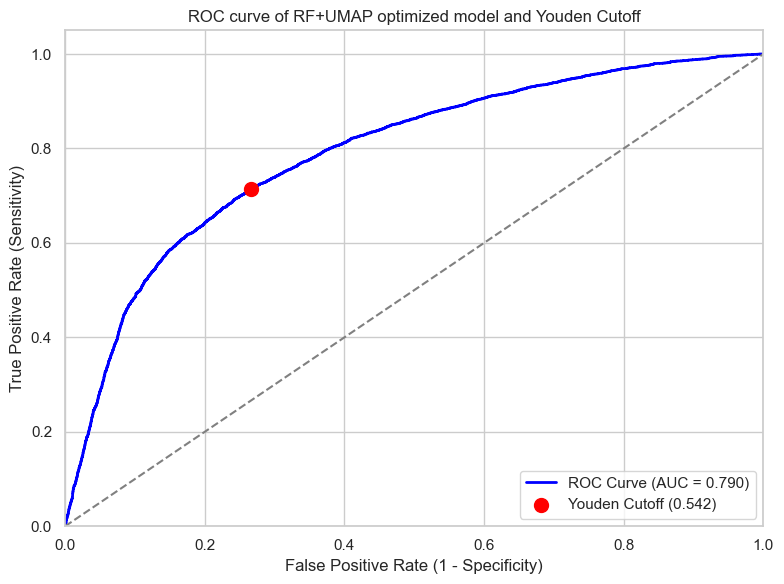

In [ ]:

# ==========================================
# 4. EVALUACIÓN DEL MODELO (CON ENFOQUE YOUDEN)
# ==========================================
# Paso A: En lugar de clases (0 o 1), obtenemos las probabilidades de la clase positiva (enfermo)
y_umap_rf_probs_opt = modelo_rf_umap_opt.predict_proba(X_test_umap)[:, 1]

# Paso B: Calcular los componentes de la curva ROC y la estadística J de Youden
fpr, tpr, thresholds = roc_curve(y_test, y_umap_rf_probs_opt)
j_scores = tpr - fpr
indice_optimo = np.argmax(j_scores)

# Extraemos el umbral de Youden óptimo
umbral_youden = 0.5421

# Paso C: Generar las nuevas predicciones binarias aplicando el umbral de Youden hallado
y_umap_rf_pred_youden = np.where(y_umap_rf_probs_opt >= umbral_youden, 1, 0)


# Imprimir las métricas de rendimiento basadas en el umbral optimizado
print(f"=== OPTIMIZACIÓN DE UMBRAL (YOUDEN) ===")
print(f"Umbral Óptimo Encontrado: {umbral_youden:.4f} ({umbral_youden * 100:.2f}%)\n")

print("=== REPORTE DE CLASIFICACIÓN RF + UMAP (CON UMBRAL YOUDEN) ===")
print(classification_report(y_test, y_umap_rf_pred_youden))

print("=== MATRIZ DE CONFUSIÓN LightGBM + PCA (CON UMBRAL YOUDEN) ===")
print(confusion_matrix(y_test, y_umap_rf_pred_youden))

print(f"\nExactitud General (Accuracy) RF + UMAP con Youden: {accuracy_score(y_test, y_umap_rf_pred_youden):.4f}")

# ==========================================
# 5. GRAFICAR LA CURVA ROC Y EL CODO
# ==========================================
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.scatter(mejor_fpr, mejor_tpr, marker='o', color='red', s=100, label=f'Youden Cutoff ({umbral_youden:.3f})', zorder=5)

plt.title('ROC curve of RF+UMAP optimized model and Youden Cutoff')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc="lower right")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig(
    'roc rf umap.tiff',
    bbox_inches='tight',
    transparent=False,
    facecolor='white'
)
plt.show()

plt.close()

In [ ]:
### PREDICCIÓN SOBRE DATASET B BAJO UMAP y RF optimizado
# 1. Usar predict_proba en lugar del clásico predict
probabilidades_rf_umap_opt = modelo_rf_umap_opt.predict_proba(dfB_escalado_umap)

# 2. Filtramos el arreglo para quedarnos solo con la probabilidad de la clase 1
probabilidades_riesgo_alto_rf_umap_opt = probabilidades_rf_umap_opt[:, 1]

# 3. Guardar estas probabilidades en el Dataset B original
dfB_con_predicciones_rf_umap_opt = dfB.copy() # B dataframe original de 219 pacientes
dfB_con_predicciones_rf_umap_opt['prob_riesgo_alto (%)'] = probabilidades_riesgo_alto_rf_umap_opt * 100

# 4. Asignar el dato real de cardio
dfB_con_predicciones_rf_umap_opt['cardio_real'] = CardioB

# 5. NUEVA PREDICCIÓN OPTIMIZADA: Aplicamos el Youden Cutoff en escala 100%
# (Asume que 'umbral_youden' viene de la celda de evaluación anterior)
umbral_youden_100 = 0.5421 * 100

dfB_con_predicciones_rf_umap_opt['prediction'] = np.where(
    dfB_con_predicciones_rf_umap_opt['prob_riesgo_alto (%)'] >= umbral_youden_100, 1, 0
)

# Desplegamos las columnas clave para verificar la consistencia del umbral
columnas_revision = ['prob_riesgo_alto (%)', 'cardio_real', 'prediction']
dfB_con_predicciones_rf_umap_opt[columnas_revision]

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


,prob_riesgo_alto (%),cardio_real,prediction
0,28.261940,0.0,0
1,86.821546,1.0,1
2,77.719338,1.0,1
3,86.471492,1.0,1
4,16.570551,0.0,0
...,...,...,...
214,84.675527,1.0,1
215,82.607707,1.0,1
216,22.631116,1.0,0
217,41.439958,1.0,0


In [ ]:
# 1. Crear columna de comparación booleana (True si acertó, False si falló)
dfB_con_predicciones_xgb_umap_opt['acierto'] = (
    dfB_con_predicciones_xgb_umap_opt['cardio_real']
    == dfB_con_predicciones_xgb_umap_opt['prediction']
)

# 2. Calcular conteos totales
total_pacientes = len(dfB_con_predicciones_xgb_umap_opt)
aciertos = dfB_con_predicciones_xgb_umap_opt['acierto'].sum()
fallos = (~dfB_con_predicciones_xgb_umap_opt['acierto']).sum()
porcentaje_acierto = (aciertos / total_pacientes) * 100

print("=== RESUMEN GENERAL DE VALIDACIÓN (N = 219) ===")
print(f"Total de pacientes: {total_pacientes}")
print(f"Aciertos:           {aciertos} ({porcentaje_acierto:.2f}%)")
print(f"Fallos:             {fallos} ({100 - porcentaje_acierto:.2f}%)")

=== RESUMEN GENERAL DE VALIDACIÓN (N = 219) ===
Total de pacientes: 219
Aciertos:           156 (71.23%)
Fallos:             63 (28.77%)


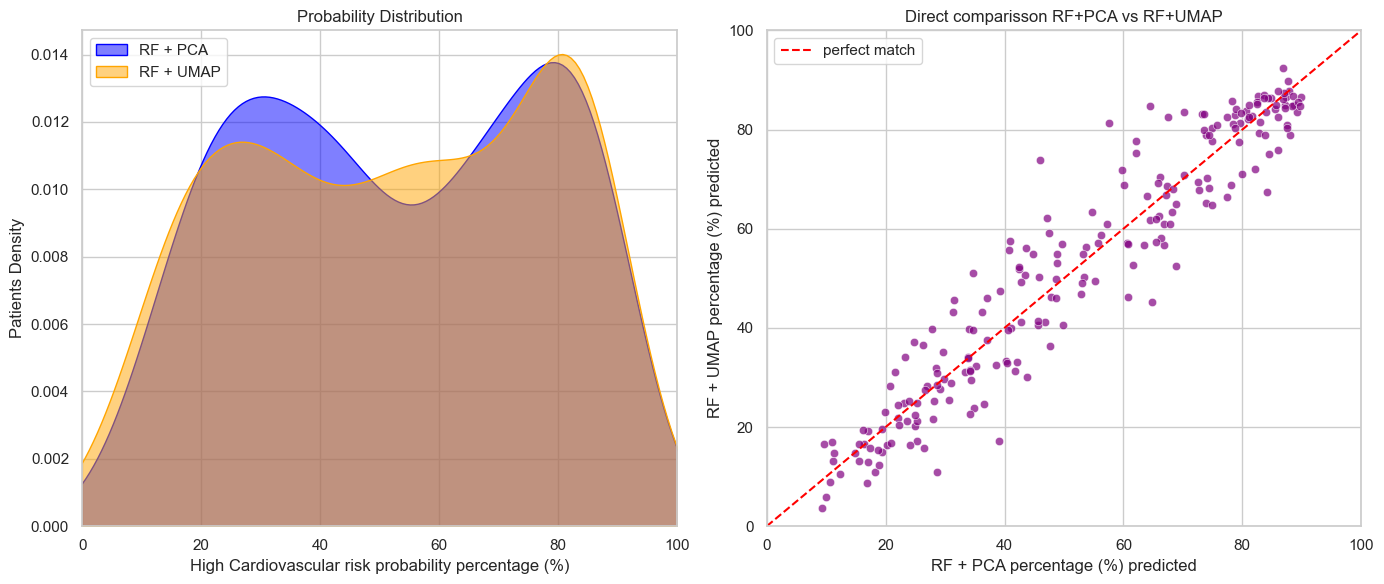

In [ ]:
# Extraer las probabilidades de ambas tablas (asumiendo que la columna se llama 'prob_riesgo_alto (%)')

prob_rf_pca = dfB_con_predicciones_rf_pca_opt['prob_riesgo_alto (%)']
prob_rf_umap = dfB_con_predicciones_rf_umap_opt['prob_riesgo_alto (%)']

# Usamos seaborn para darle un estilo moderno y limpio con cuadrícula
sns.set_theme(style="whitegrid")
# Crear una figura con 1 fila y 2 columnas para poner los gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================
# 3. GRÁFICA 1: DISTRIBUCIÓN DE PROBABILIDADES
# ==========================================
# ax=axes[0] indica que va en el lado izquierdo. fill=True rellena el área de color.
sns.kdeplot(prob_rf_pca, fill=True, color="blue", label="RF + PCA", ax=axes[0], alpha=0.5)
sns.kdeplot(prob_rf_umap, fill=True, color="orange", label="RF + UMAP", ax=axes[0], alpha=0.5)

axes[0].set_title('Probability Distribution')
axes[0].set_xlabel('High Cardiovascular risk probability percentage (%)')
axes[0].set_ylabel('Patients Density')
axes[0].set_xlim(0, 100) # Fijar el límite del eje X de 0 a 100
axes[0].legend()

# ==========================================
# 4. GRÁFICA 2: COMPARACIÓN PACIENTE POR PACIENTE
# ==========================================
# ax=axes[1] indica que va en el lado derecho. Cada punto es un paciente.
sns.scatterplot(x=prob_rf_pca, y=prob_rf_umap, alpha=0.7, color="purple", ax=axes[1])

# Dibujamos una línea diagonal roja perfecta (si y=x)
# Si un punto cae en esta línea, significa que PCA y UMAP dieron exactamente el mismo %
axes[1].plot([0, 100], [0, 100], color='red', linestyle='--', label='perfect match')

axes[1].set_title('Direct comparisson RF+PCA vs RF+UMAP')
axes[1].set_xlabel('RF + PCA percentage (%) predicted')
axes[1].set_ylabel('RF + UMAP percentage (%) predicted')
axes[1].set_xlim(0, 100) # Ejes de 0 a 100
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.savefig(
    'comparisson rf pca umap.tiff',
    bbox_inches='tight',
    transparent=False,
    facecolor='white'
)
plt.show()

plt.close()

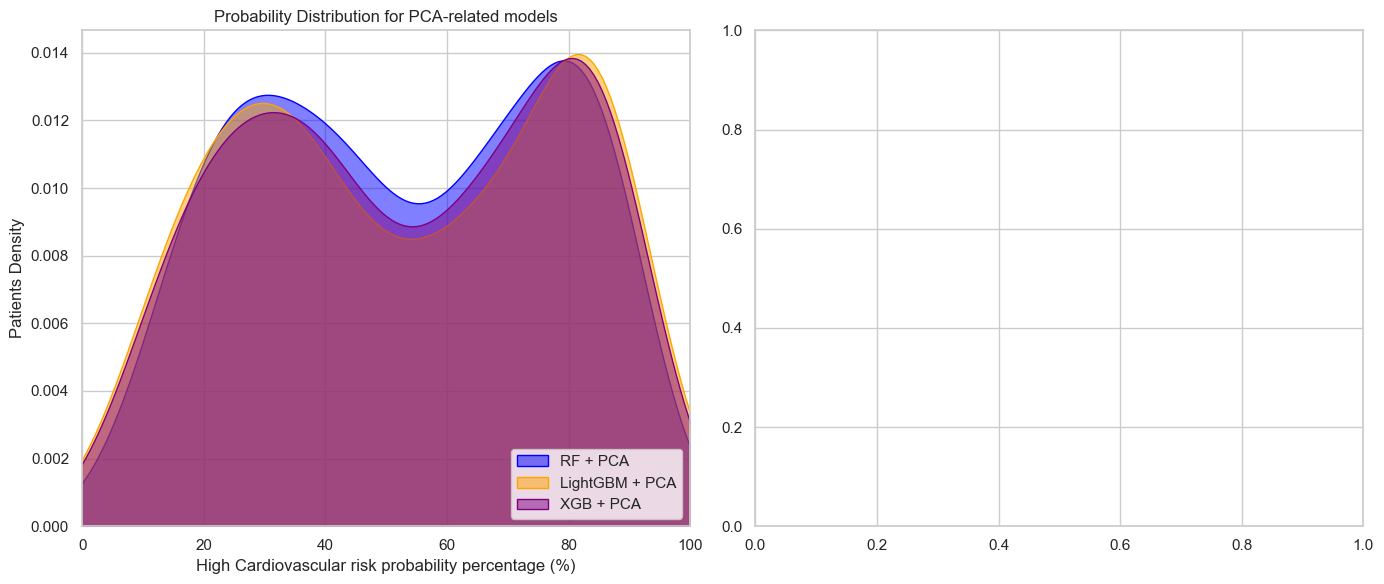

In [ ]:
# Extraer las probabilidades de ambas tablas (asumiendo que la columna se llama 'prob_riesgo_alto (%)')

# Usamos seaborn para darle un estilo moderno y limpio con cuadrícula
sns.set_theme(style="whitegrid")
# Crear una figura con 1 fila y 2 columnas para poner los gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================
# 3. GRÁFICA 1: DISTRIBUCIÓN DE PROBABILIDADES
# ==========================================
# ax=axes[0] indica que va en el lado izquierdo. fill=True rellena el área de color.
sns.kdeplot(prob_rf_pca, fill=True, color="blue", label="RF + PCA", ax=axes[0], alpha=0.5)
sns.kdeplot(prob_lgbm_pca, fill=True, color="orange", label="LightGBM + PCA", ax=axes[0], alpha=0.5)
sns.kdeplot(prob_xgb_pca, fill=True, color="purple", label="XGB + PCA", ax=axes[0], alpha=0.5)

axes[0].set_title('Probability Distribution for PCA-related models')
axes[0].set_xlabel('High Cardiovascular risk probability percentage (%)')
axes[0].set_ylabel('Patients Density')
axes[0].set_xlim(0, 100) # Fijar el límite del eje X de 0 a 100
axes[0].legend()

plt.tight_layout()
plt.savefig(
    'probability pca related.tiff',
    bbox_inches='tight',
    transparent=False,
    facecolor='white'
)
plt.show()

plt.close()

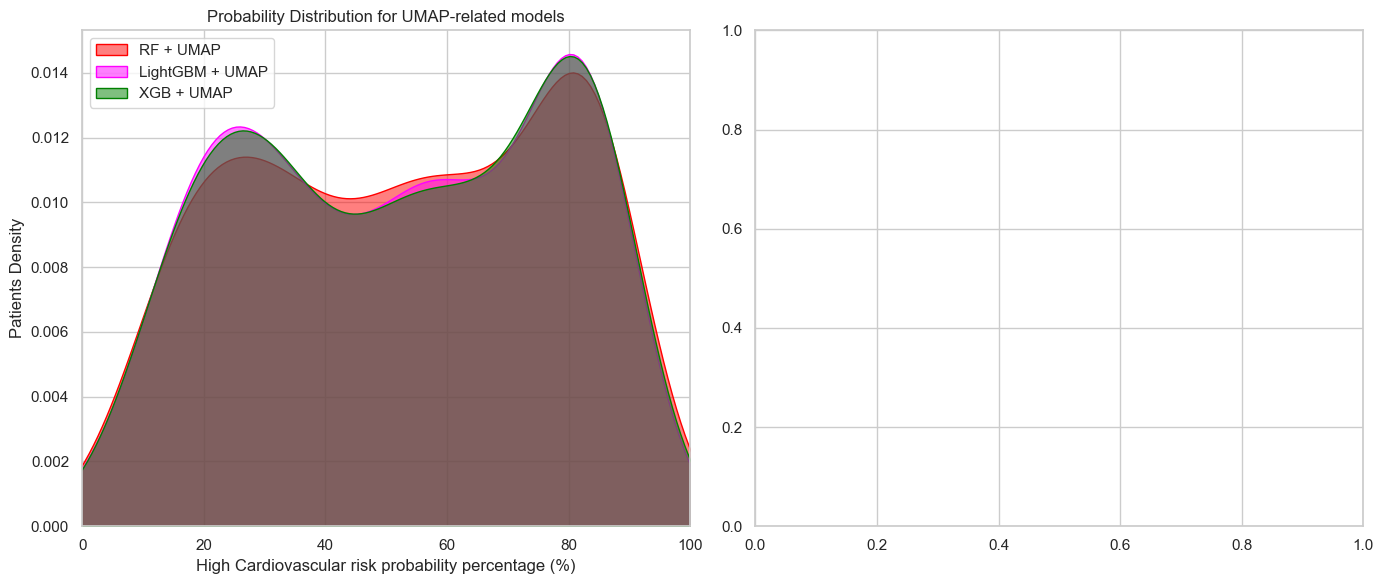

In [ ]:
# Extraer las probabilidades de ambas tablas (asumiendo que la columna se llama 'prob_riesgo_alto (%)')

# Usamos seaborn para darle un estilo moderno y limpio con cuadrícula
sns.set_theme(style="whitegrid")
# Crear una figura con 1 fila y 2 columnas para poner los gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================
# 3. GRÁFICA 1: DISTRIBUCIÓN DE PROBABILIDADES
# ==========================================
# ax=axes[0] indica que va en el lado izquierdo. fill=True rellena el área de color.
sns.kdeplot(prob_rf_umap, fill=True, color="red", label="RF + UMAP", ax=axes[0], alpha=0.5)
sns.kdeplot(prob_lgbm_umap, fill=True, color="magenta", label="LightGBM + UMAP", ax=axes[0], alpha=0.5)
sns.kdeplot(prob_xgb_umap, fill=True, color="green", label="XGB + UMAP", ax=axes[0], alpha=0.5)

axes[0].set_title('Probability Distribution for UMAP-related models')
axes[0].set_xlabel('High Cardiovascular risk probability percentage (%)')
axes[0].set_ylabel('Patients Density')
axes[0].set_xlim(0, 100) # Fijar el límite del eje X de 0 a 100
axes[0].legend()

plt.tight_layout()
plt.savefig(
    'probability umap related.tiff',
    bbox_inches='tight',
    transparent=False,
    facecolor='white'
)
plt.show()

plt.close()

In [10]:
from sklearn.cluster import KMeans

CLUSTERING CON KMEANS Y DBSCAN

Calculando distancias espaciales para el Método del Codo...


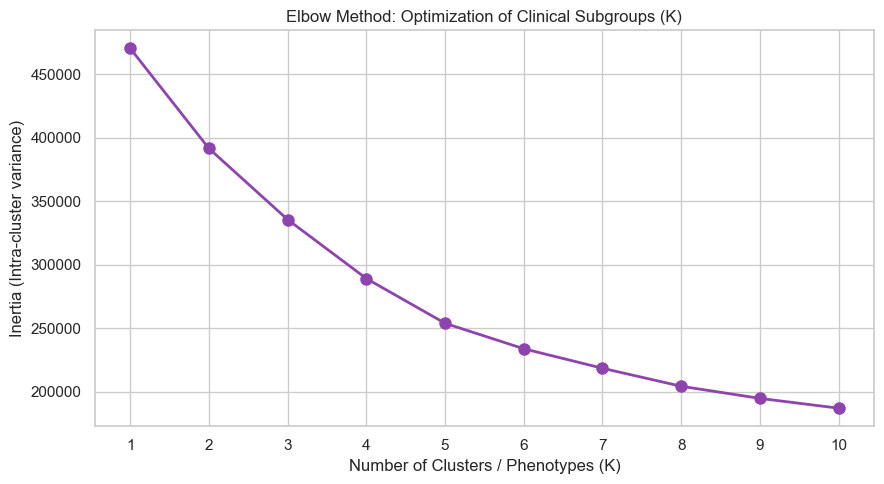

In [ ]:


# ==========================================
# 1. CÁLCULO DE LA INERCIA (ELBOW METHOD)
# ==========================================
inercia = []
rango_k = range(1, 11) # Probaremos desde 1 hasta 10 posibles fenotipos

print("Calculando distancias espaciales para el Método del Codo...")
for k in rango_k:
    # n_init=10 asegura que el algoritmo pruebe 10 inicios aleatorios y se quede con el mejor
    kmeans_prueba = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_prueba.fit(X_train_pca) # K-Means es ciego, NO le pasamos la variable 'y'
    inercia.append(kmeans_prueba.inertia_)

# ==========================================
# 2. VISUALIZACIÓN DEL CODO
# ==========================================
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

plt.plot(rango_k, inercia, marker='o', linestyle='-', color='#8e44ad', linewidth=2, markersize=8)
plt.title('Elbow Method: Optimization of Clinical Subgroups (K)')
plt.xlabel('Number of Clusters / Phenotypes (K)')
plt.ylabel('Inertia (Intra-cluster variance)')
plt.xticks(rango_k)

plt.tight_layout()
plt.savefig(
    'elbow kmeans.pdf',
    bbox_inches='tight',
    transparent=False,
    facecolor='white'
)
plt.show()

plt.close()

In [ ]:
# ==========================================
# 1. PREPARACIÓN DE DATOS con PCA (DATASET A)
# ==========================================
# Definir X_pca usando PCA
# X_pca = dfA_escalado_pca
# Definir 'y' con la columna cardio original del Dataset A
#y = cardioA

# ==========================================
# 2. DIVISIÓN DE ENTRENAMIENTO Y PRUEBA
# ==========================================
#X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(dfA, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
from sklearn.cluster import KMeans

In [11]:



# ==========================================
# 1. ENTRENAMIENTO DEL MODELO K-MEANS FINAL
# ==========================================
k_optimo = 5 # (Tú elegiste 5 según el codo)
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

# fit_predict asigna a cada paciente a la caja 0, 1, 2, 3 o 4
fenotipos_train = kmeans.fit_predict(X_train_scaled)

# ==========================================
# 2. INTEGRACIÓN (SIN FILTRO REDUNDANTE)
# ==========================================
# Creamos una copia para el análisis (X_train_raw ya viene limpio del principio)
df_analisis_clinico = X_train_raw.copy()
df_analisis_clinico['Fenotipe'] = fenotipos_train
df_analisis_clinico['Cardio_Real'] = y_train

# Renombramos para mantener compatibilidad con el resto de tu código
df_limpio_tabla = df_analisis_clinico.copy()

# ==========================================
# 3. IDENTIFICAR VARIABLES Y CALCULAR POR SEPARADO
# ==========================================
# ATENCIÓN: Quitamos 'ap_lo' de esta lista también
variables_continuas = ['age', 'height', 'weight', 'ap_hi']

# ATENCIÓN: Cambiamos 'cardio' por 'Cardio_Real' que es como la llamaste arriba
variables_categoricas = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'Cardio_Real']

# A. Continuas: Media simple
tabla_continuas = df_limpio_tabla.groupby('Fenotipe')[variables_continuas].mean()

# B. Categóricas: Moda (el valor más frecuente)
import numpy as np
tabla_categoricas = df_limpio_tabla.groupby('Fenotipe')[variables_categoricas].agg(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
)

# ==========================================
# 4. UNIFICACIÓN DE LA TABLA CLÍNICA FINAL
# ==========================================
# Juntamos ambas tablas lado a lado
tabla_final = pd.concat([tabla_continuas, tabla_categoricas], axis=1)

# Añadimos el conteo de pacientes válidos por clúster
tabla_final['Total_Valid'] = df_limpio_tabla.groupby('Fenotipe').size()

print("\n=== CARACTERÍSTICAS CLÍNICAS DE LOS FENOTIPOS DESCUBIERTOS ===")
# Transponemos para que sea idéntica a la "Tabla 1" de cualquier paper médico
print(tabla_final.T.round(2))


=== CARACTERÍSTICAS CLÍNICAS DE LOS FENOTIPOS DESCUBIERTOS ===
Fenotipe            0        1        2         3        4
age             52.89    52.44    55.88     53.17    53.29
height           1.71     1.68     1.63      1.61     1.64
weight          77.43    78.18    79.10     71.21    73.39
ap_hi          128.05   129.15   133.51    125.16   126.13
gender           2.00     2.00     1.00      1.00     1.00
cholesterol      1.00     1.00     3.00      1.00     1.00
gluc             1.00     1.00     3.00      1.00     1.00
smoke            0.00     1.00     0.00      0.00     0.00
alco             0.00     1.00     0.00      0.00     0.00
active           1.00     1.00     1.00      1.00     0.00
Cardio_Real      0.00     0.00     1.00      0.00     1.00
Total_Valid  13181.00  2963.00  5451.00  24956.00  9228.00


In [ ]:
# ==========================================
# 1. ENTRENAMIENTO DEL MODELO K-MEANS FINAL sobre validacion
# ==========================================
k_optimo = 5 # (Tú elegiste 5 según el codo)
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

# fit_predict asigna a cada paciente a la caja 0, 1, 2, 3 o 4
fenotipos_train = kmeans.fit_predict(dfB_scaled)

# ==========================================
# 2. INTEGRACIÓN (SIN FILTRO REDUNDANTE)
# ==========================================
# Creamos una copia para el análisis (X_train_raw ya viene limpio del principio)
df_analisis_clinico = dfB.copy()
df_analisis_clinico['Fenotipe'] = fenotipos_train
df_analisis_clinico['Cardio_Real'] = CardioB

# Renombramos para mantener compatibilidad con el resto de tu código
df_limpio_tabla = df_analisis_clinico.copy()

# ==========================================
# 3. IDENTIFICAR VARIABLES Y CALCULAR POR SEPARADO
# ==========================================
# ATENCIÓN: Quitamos 'ap_lo' de esta lista también
variables_continuas = ['age', 'height', 'weight', 'ap_hi']

# ATENCIÓN: Cambiamos 'cardio' por 'Cardio_Real' que es como la llamaste arriba
variables_categoricas = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'Cardio_Real']

# A. Continuas: Media simple
tabla_continuas = df_limpio_tabla.groupby('Fenotipe')[variables_continuas].mean()

# B. Categóricas: Moda (el valor más frecuente)
import numpy as np
tabla_categoricas = df_limpio_tabla.groupby('Fenotipe')[variables_categoricas].agg(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
)

# ==========================================
# 4. UNIFICACIÓN DE LA TABLA CLÍNICA FINAL
# ==========================================
# Juntamos ambas tablas lado a lado
tabla_final = pd.concat([tabla_continuas, tabla_categoricas], axis=1)

# Añadimos el conteo de pacientes válidos por clúster
tabla_final['Total_Valid'] = df_limpio_tabla.groupby('Fenotipe').size()

print("\n=== CARACTERÍSTICAS CLÍNICAS DE LOS FENOTIPOS DESCUBIERTOS ===")
# Transponemos para que sea idéntica a la "Tabla 1" de cualquier paper médico
print(tabla_final.T.round(2))


=== CARACTERÍSTICAS CLÍNICAS DE LOS FENOTIPOS DESCUBIERTOS ===
Fenotipe          0       1       2       3       4
age           52.50   51.90   54.02   53.68   54.53
height         1.72    1.61    1.65    1.68    1.62
weight        76.41   67.39   75.93   70.05   79.72
ap_hi        131.30  125.14  128.93  133.18  141.97
gender         2.00    1.00    1.00    2.00    1.00
cholesterol    1.00    1.00    1.00    1.00    3.00
gluc           1.00    1.00    1.00    1.00    1.00
smoke          0.00    0.00    0.00    1.00    0.00
alco           0.00    0.00    0.00    0.00    0.00
active         1.00    1.00    0.00    1.00    1.00
Cardio_Real    0.00    0.00    0.00    0.00    1.00
Total_Valid   44.00   77.00   44.00   22.00   32.00


# ================================================================================
# CLUESTERING PREVALENCE CALCULATION
# ===============================================================================

In [ ]:
"""
Step 0 / Reviewer-3 leakage audit for Pathway II's unsupervised branch.

Reproduces the K-Means phenotyping exactly as the notebook (k=5, seed=42, on the
ten STANDARDISED input features; `cardio` is NOT a feature), and then, for each
cluster, reports:
  * the TRUE prevalence of cardio (mean) to 6 decimals and as raw counts n+/n,
  * the MODE of cardio (the majority class) -- i.e. the value the manuscript
    Tables 4/5 actually reported, which for a binary variable is always 0 or 1.
It quantifies the cluster<->cardio association with normalized mutual
information (NMI) and Cramer's V, and runs a label-permutation test
(2000 shuffles) to place the true association in the null distribution.
"""

RS = 42
HERE = os.path.dirname(os.path.abspath(__file__)); DATA = os.path.join(HERE, "data")

# ---- load exactly as the notebook ----
dfA = pd.read_csv(os.path.join(DATA,"cardio_train_1.csv"), sep=';')
dfA['age'] = dfA['age']/365; dfA['height'] = dfA['height']/100; dfA.drop('id',axis=1,inplace=True)
dfB = pd.read_csv(os.path.join(DATA,"3-Variables-to-cardiovascular-disease.csv"), sep=',').dropna()
CardioB = dfB['cardio'].values.astype(int)
dfB["height"]=dfB["height"]/100; dfB.rename(columns={'age_years':'age'},inplace=True)
for c in ["id ",'cardio','bmi']: dfB.drop(c,axis=1,inplace=True)

biolog = dict(ap_hi=(60,250), height=(1.00,2.20), weight=(35,250))
dfA2 = dfA.copy(); dfA2.drop('ap_lo',axis=1,inplace=True)
mask = ((dfA2.ap_hi>=60)&(dfA2.ap_hi<=250)&(dfA2.height>=1.0)&(dfA2.height<=2.2)&(dfA2.weight>=35)&(dfA2.weight<=250))
dfA2l = dfA2[mask].copy(); cardioA = dfA2l['cardio'].values.astype(int); dfA2l.drop('cardio',axis=1,inplace=True)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    dfA2l, cardioA, test_size=0.2, random_state=RS, stratify=cardioA)
dfB = dfB[X_train_raw.columns]
esc = StandardScaler().fit(X_train_raw)                 # <-- fit on TRAIN only
X_train_s = esc.transform(X_train_raw); dfB_s = esc.transform(dfB)

FEATURES = list(X_train_raw.columns)
assert 'cardio' not in FEATURES, "cardio must not be a clustering feature"

def cramers_v(labels, y):
    ct = pd.crosstab(labels, y); chi2 = chi2_contingency(ct)[0]
    n = ct.values.sum(); k = min(ct.shape)-1
    return float(np.sqrt(chi2/(n*k))) if k>0 else float('nan')

def audit(X_s, y, name):
    km = KMeans(n_clusters=5, random_state=RS, n_init=10)
    lab = km.fit_predict(X_s)
    rows=[]
    for c in sorted(np.unique(lab)):
        yc = y[lab==c]; n=len(yc); npos=int(yc.sum())
        rows.append(dict(cluster=int(c), n=n, n_pos=npos, n_neg=n-npos,
                         prevalence=round(npos/n,6), mode=int(np.mean(yc)>=0.5)))
    nmi = normalized_mutual_info_score(lab, y)
    v = cramers_v(lab, y)
    # permutation test: shuffle y, recompute NMI vs fixed clusters
    rng = np.random.default_rng(RS); nperm=2000; null=np.empty(nperm)
    for i in range(nperm):
        null[i] = normalized_mutual_info_score(lab, rng.permutation(y))
    p = (np.sum(null>=nmi)+1)/(nperm+1)
    res = dict(cohort=name, n_total=int(len(y)), overall_prevalence=round(float(y.mean()),6),
               clusters=rows, NMI=round(float(nmi),4), cramers_V=round(v,4),
               NMI_null_mean=round(float(null.mean()),4), NMI_null_p95=round(float(np.percentile(null,95)),4),
               NMI_null_max=round(float(null.max()),4), perm_p_value=round(float(p),5), n_perm=nperm)
    return res, rows

print("Clustering features (cardio absent):", FEATURES)
print("Scaler fit on training partition only; interval filtering uses ap_hi/height/weight bounds only.\n")

out=[]
for X_s, y, name in [(X_train_s, y_train, "Training split (Table 4)"), (dfB_s, CardioB, "Validation cohort n=219 (Table 5)")]:
    res, rows = audit(X_s, y, name)
    out.append(res)
    print(f"===== {name} =====  overall prevalence = {res['overall_prevalence']:.4f}")
    print(f"{'cluster':>7} {'n':>7} {'n_pos':>6} {'n_neg':>6} {'prevalence':>11} {'MODE(reported)':>15}")
    for r in rows:
        print(f"{r['cluster']:>7} {r['n']:>7} {r['n_pos']:>6} {r['n_neg']:>6} {r['prevalence']:>11.4f} {r['mode']:>15}")
    print(f"  NMI(cluster,cardio) = {res['NMI']:.4f} | Cramer's V = {res['cramers_V']:.4f}")
    print(f"  Permutation null: mean NMI = {res['NMI_null_mean']:.4f}, p95 = {res['NMI_null_p95']:.4f}, "
          f"max = {res['NMI_null_max']:.4f}; p = {res['perm_p_value']:.4g}\n")

json.dump(out, open(os.path.join(HERE,"leakage_audit_results.json"),"w"), indent=2)
print("Saved leakage_audit_results.json")